# Selected channel-timeseries clustering: embedding scatterplots & model selection

## tl;dr

- Channel analogue of `voxel_timeseries_cluster_scatterplots.ipynb`: same six spatial
  embeddings (PCA, MDS, Isomap, t-SNE, FastICA, UMAP) of the z-scored, 50-component-PCA-
  denoised model-embedding channel time series, each clustered with K-means, HDBSCAN, and
  BIRCH — but the points being embedded/clustered are **model channels**, not cortical
  grayordinates. The reducer grid, dimension criteria, elbow-selection math, clustering
  grid, and clustering selection score are the same code imported unchanged from the voxel
  module (`channel_timeseries_model_selection.py` docstring).
- The notebook is **parameterized over model family** (config cell below); it has been run
  here for the default family. `nemotron_layer18_mp` and `peav` also have completed sweeps
  and can be selected the same way.
- **Beyond the voxel notebook**, this one also plots the elbow-selected "latent-best"
  dimension's cluster labels — not just the 2-D/3-D display embeddings used for looking —
  because for channels, unlike grayordinates, a handful of extra dimensions is what
  actually carries most of the reduction's information; Section 5 shows whether the
  clusters visible in the 2-D/3-D pictures survive once the fuller embedding is used to
  find them, with adjusted Rand index (ARI) numbers quantifying the agreement.
- All channels are plotted in every scatterplot — no display subsampling. Gray points are
  HDBSCAN noise/unassigned channels. Cluster IDs and geometry are algorithm-specific;
  matching colors across panels do **not** imply homologous channel groups.


## Context & methods

The source is the z-scored channel time series (one row per model channel: the model's
per-channel activation trace over the movie) reduced through the shared 50-component
preprocessing PCA. Two independent hyperparameter sweeps ran before these plots were made,
via `channel_timeseries_model_selection.py`:

1. **Reducer sweep** (Section 1): for each method, candidate output dimensions were
   scored by a fixed-sample geometry-quality score,
   `0.4 x mean trustworthiness + 0.4 x mean continuity + 0.2 x rescaled Spearman
   distance-rank agreement` (all on `[0, 1]`), evaluated at multiple neighborhood sizes.
   The 2-D and 3-D display embeddings pick, at that fixed dimension, whichever swept
   hyperparameter setting has the best geometry-quality score. A separate, per-method
   "latent-best" dimension is chosen by a diminishing-returns elbow on that method's own
   native criterion (explained variance for PCA, stress for MDS, etc.) — the point of
   maximum vertical distance above the straight line connecting the smallest and largest
   tested dimension's criterion values.
2. **Clustering sweep** (Section 2): for every selected 2-D/3-D/latent-best embedding,
   K-means, HDBSCAN, and BIRCH were swept over their hyperparameter grids and scored by
   `0.35 x silhouette + 0.20 x 1/(1+Davies-Bouldin) + 0.15 x Calinski-Harabasz/(Calinski-Harabasz+1000)
   + 0.15 x cluster-size balance (normalized entropy) + 0.15 x assigned-data fraction (1 - noise fraction)`.
   HDBSCAN's `min_cluster_size` is rescaled by the ratio of full-channel-set to
   evaluation-sample size before the final full-channel-set fit (in practice a no-op here:
   the evaluation sample already covers every channel for these families).

A small number of (reducer, clusterer) combinations have no valid clustering at any
hyperparameter setting — e.g. BIRCH sometimes collapses to a single cluster across its
whole grid for a low-signal `latent_best` reducer — and are skipped rather than failing the
sweep; where this happens for the active family it is reported explicitly below (Section 0
setup and Section 5), not silently hidden.

### Key assumptions

- Scatterplots diagnose separation in embedding space; they do not establish that channels
  sharing a cluster are functionally interchangeable.
- All channels are plotted; small, low-alpha, rasterized markers keep the figures legible.
- `selected_clusterings_combined.csv` / the per-map CSVs remain authoritative for
  channel-to-cluster lookups; these scatterplots show separation in reduced embedding
  space only.


## Config — choose the model family

In [1]:
# ============================================================================
# CONFIG — the only cell you need to change to switch families.
# Valid choices are any family with a completed _channel_timeseries_model_selection
# sweep under outputs/cluster/<family>/. As of this run:
#   "topoomni_layer18_sheet_mp"  (default; 2048 channels)
#   "nemotron_layer18_mp"        (2048 channels)
#   "peav"                       (1024 channels)
# ============================================================================
FAMILY = "topoomni_layer18_sheet_mp"
# ============================================================================


## Data & setup

In [2]:
%matplotlib inline
from pathlib import Path
import json

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score
from IPython.display import display, Markdown

SELECTION_ROOT = Path(
    f"/home/amin/Research/Representation/Movie/outputs/cluster/{FAMILY}/"
    "_channel_timeseries_model_selection/norm-zscore_prepca50"
)
FIGURE_DIR = SELECTION_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
for stale in list(FIGURE_DIR.glob("*.png")) + list(FIGURE_DIR.glob("*.csv")):
    stale.unlink()

REDUCTION_ORDER = ["pca", "mds", "isomap", "tsne", "fastica", "umap"]
DISPLAY_NAMES = {"pca": "PCA", "mds": "MDS", "isomap": "Isomap", "tsne": "t-SNE",
                  "fastica": "FastICA", "umap": "UMAP"}
CLUSTER_DISPLAY = {"kmeans": "K-means", "hdbscan": "HDBSCAN", "birch": "BIRCH"}
CLUSTER_ORDER = ["kmeans", "hdbscan", "birch"]

selected_reducers = pd.read_csv(SELECTION_ROOT / "selected_reducers.csv")
selected_clusterings = pd.read_csv(SELECTION_ROOT / "selected_clusterings.csv")
dim_sweep = pd.read_csv(SELECTION_ROOT / "dimension_selection_sweep.csv")
latent_summary = pd.read_csv(SELECTION_ROOT / "selected_latent_dimensions.csv")
cluster_sweep = pd.read_csv(SELECTION_ROOT / "clustering_sweep.csv")
map_manifest = json.loads((SELECTION_ROOT / "selected_maps_manifest.json").read_text())

n_channels = int(np.load(selected_reducers.iloc[0]["embedding"], mmap_mode="r").shape[0])

assert set(REDUCTION_ORDER) == set(selected_reducers["method"])
assert selected_reducers["selection_role"].str.contains("display_2d").sum() == 6
assert selected_reducers["selection_role"].str.contains("display_3d").sum() == 6
assert selected_reducers["selection_role"].str.contains("latent_best").sum() == 6
assert len(selected_clusterings) <= len(selected_reducers) * 3
assert len(map_manifest) == len(selected_clusterings)

expected_combos = {
    (m, role, c) for m in REDUCTION_ORDER
    for role in ("display_2d", "display_3d", "latent_best")
    for c in CLUSTER_ORDER
}
observed_combos = set(zip(
    selected_clusterings["reduction_method"],
    selected_clusterings["selection_role"],
    selected_clusterings["method"],
))
missing_combos = sorted(expected_combos - observed_combos)

print(f"Family: {FAMILY}  |  channels: {n_channels}")
print(f"{len(selected_clusterings)}/{len(expected_combos)} (reducer, role, clusterer) "
      f"combinations have a valid full-channel-set clustering.")
if missing_combos:
    print(f"{len(missing_combos)} combinations skipped (no valid clustering at any "
          f"hyperparameter setting for that combo):")
    for method, role, clusterer in missing_combos:
        print(f"  - {method} / {role} / {clusterer}")
else:
    print("No combinations skipped.")

display(selected_reducers[[
    "method", "selection_role", "n_components", "quality_score",
    "dimension_criterion", "dimension_criterion_value",
]].sort_values(["method", "selection_role"]).reset_index(drop=True))


Family: topoomni_layer18_sheet_mp  |  channels: 2048
51/54 (reducer, role, clusterer) combinations have a valid full-channel-set clustering.
3 combinations skipped (no valid clustering at any hyperparameter setting for that combo):
  - fastica / latent_best / birch
  - mds / latent_best / birch
  - pca / latent_best / birch


,method,selection_role,n_components,quality_score,dimension_criterion,dimension_criterion_value
0,fastica,display_2d,2,0.875381,normalized_reconstruction_mse,0.574694
1,fastica,display_3d,3,0.932675,normalized_reconstruction_mse,0.457488
2,fastica,latent_best,8,0.944815,normalized_reconstruction_mse,0.268184
3,isomap,display_2d,2,0.886255,geodesic_reconstruction_error,454.835500
4,isomap,display_3d,3,0.945727,geodesic_reconstruction_error,329.953625
5,isomap,latent_best,6,0.979115,geodesic_reconstruction_error,228.911094
6,mds,display_2d,2,0.763958,normalized_stress,0.343831
7,mds,display_3d,3,0.541320,normalized_stress,0.371878
8,mds,latent_best,12,0.555525,normalized_stress,0.234314
9,pca,display_2d,2,0.880712,explained_variance_fraction_of_prepca,0.425306


## Section 1: Dimensionality selection (6 figures, one per reducer)

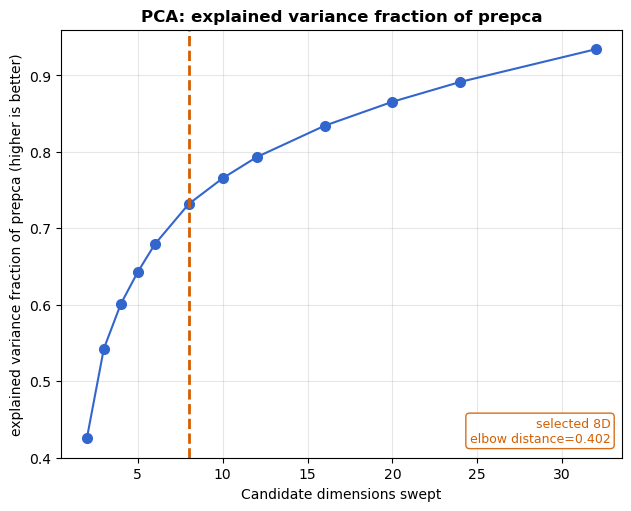

### PCA

**Hyperparameters this method sweeps:** none beyond the output dimension itself.

**Why 8-D won:** the diminishing-returns elbow on explained variance fraction of prepca (`maximize` is better) sits at 8 components — the point of maximum vertical distance (0.402) above the straight line connecting the smallest and largest tested dimension. Candidates tested: [2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32].

,selection_role,n_components,quality_score,dimension_criterion_value
0,display_2d,2,0.880712,0.425306
1,display_3d,3,0.940599,0.542512
2,latent_best,8,0.987071,0.731816


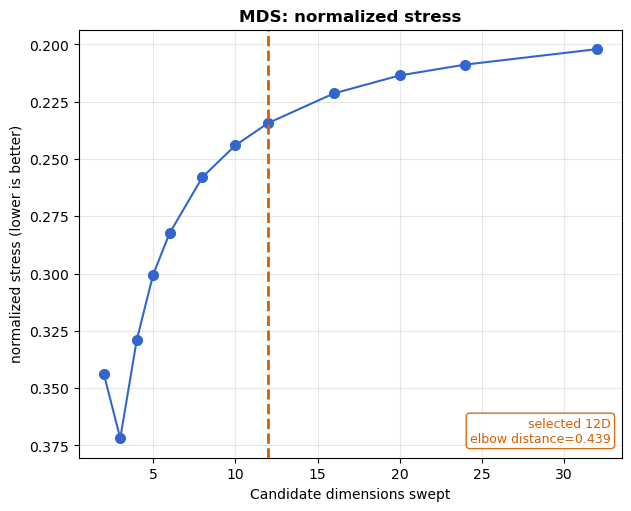

### MDS

**Hyperparameters this method sweeps:**
- `n_landmarks`: how many channels are fit directly (exact but expensive); the rest are placed by extension
- `extension_neighbors`: how many landmark neighbors each remaining point is interpolated from (distance-weighted kNN extension)
- `mds_max_iterations`: SMACOF stress-majorization optimizer iteration budget

**Why 12-D won:** the diminishing-returns elbow on normalized stress (`minimize` is better) sits at 12 components — the point of maximum vertical distance (0.439) above the straight line connecting the smallest and largest tested dimension. Candidates tested: [2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32].

,selection_role,n_components,quality_score,dimension_criterion_value,n_landmarks,extension_neighbors,mds_max_iterations
0,display_2d,2,0.763958,0.343831,2000.0,4.0,300.0
1,display_3d,3,0.541320,0.371878,1000.0,8.0,300.0
2,latent_best,12,0.555525,0.234314,1000.0,4.0,300.0


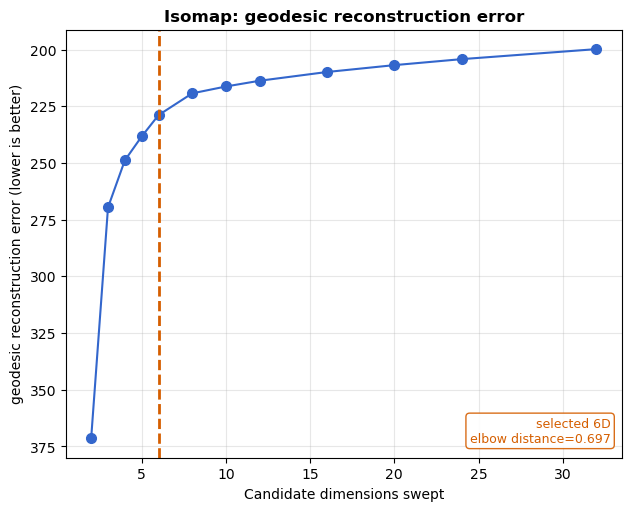

### Isomap

**Hyperparameters this method sweeps:**
- `n_landmarks`: how many channels are fit directly (exact but expensive); the rest are placed by extension
- `isomap_neighbors`: neighbors used to build the geodesic graph approximating manifold distances

**Why 6-D won:** the diminishing-returns elbow on geodesic reconstruction error (`minimize` is better) sits at 6 components — the point of maximum vertical distance (0.697) above the straight line connecting the smallest and largest tested dimension. Candidates tested: [2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32].

,selection_role,n_components,quality_score,dimension_criterion_value,n_landmarks,isomap_neighbors
0,display_2d,2,0.886255,454.835500,2000.0,30.0
1,display_3d,3,0.945727,329.953625,2000.0,30.0
2,latent_best,6,0.979115,228.911094,1000.0,50.0


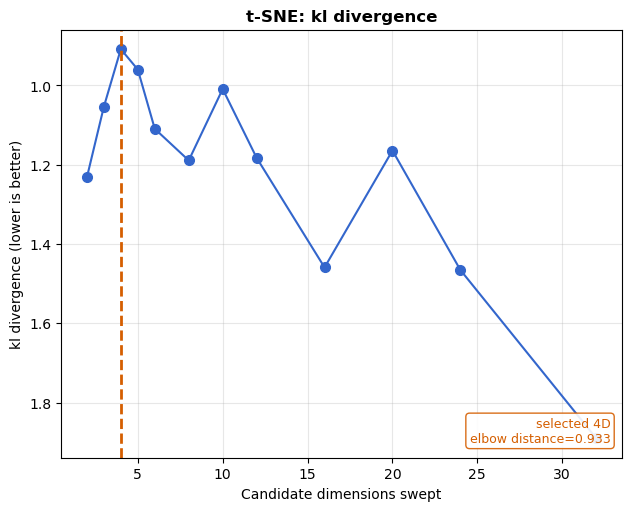

### t-SNE

**Hyperparameters this method sweeps:**
- `n_landmarks`: how many channels are fit directly (exact but expensive); the rest are placed by extension
- `extension_neighbors`: how many landmark neighbors each remaining point is interpolated from (distance-weighted kNN extension)
- `tsne_perplexity`: effective neighborhood size t-SNE balances between local and global structure
- `tsne_iterations`: gradient-descent iteration budget

**Why 4-D won:** the diminishing-returns elbow on kl divergence (`minimize` is better) sits at 4 components — the point of maximum vertical distance (0.933) above the straight line connecting the smallest and largest tested dimension. Candidates tested: [2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32].

,selection_role,n_components,quality_score,dimension_criterion_value,n_landmarks,extension_neighbors,tsne_perplexity,tsne_iterations
0,display_2d,2,0.918659,1.597456,2000.0,4.0,50.0,1000.0
1,display_3d,3,0.941976,1.338211,2000.0,4.0,50.0,1000.0
2,latent_best,4,0.929742,0.908315,1000.0,4.0,50.0,1000.0


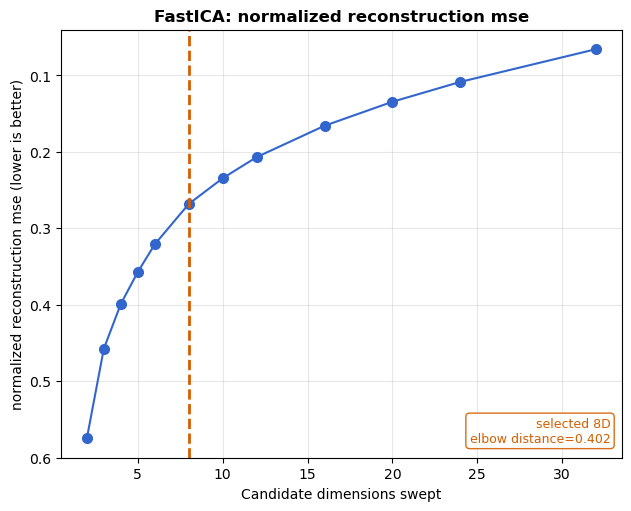

### FastICA

**Hyperparameters this method sweeps:**
- `fastica_algorithm`: component-extraction order ('parallel' vs 'deflation')
- `fastica_fun`: non-Gaussianity contrast function used to separate independent components
- `fastica_max_iterations`: fixed-point iteration budget

**Why 8-D won:** the diminishing-returns elbow on normalized reconstruction mse (`minimize` is better) sits at 8 components — the point of maximum vertical distance (0.402) above the straight line connecting the smallest and largest tested dimension. Candidates tested: [2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32].

,selection_role,n_components,quality_score,dimension_criterion_value,fastica_algorithm,fastica_fun,fastica_max_iterations
0,display_2d,2,0.875381,0.574694,deflation,cube,1000.0
1,display_3d,3,0.932675,0.457488,parallel,logcosh,1000.0
2,latent_best,8,0.944815,0.268184,deflation,cube,1000.0


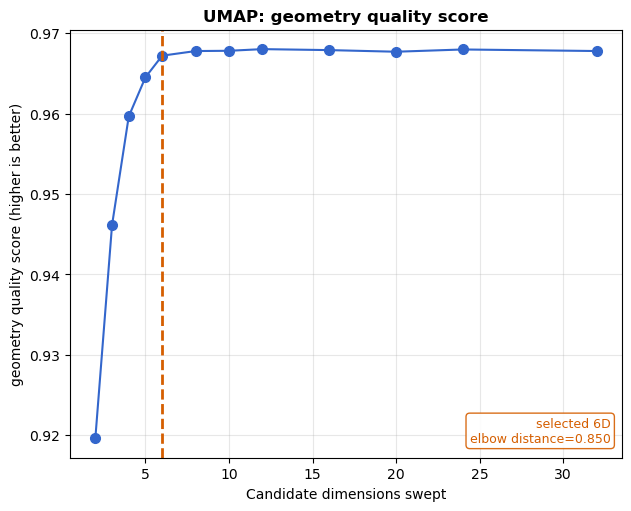

### UMAP

**Hyperparameters this method sweeps:**
- `n_landmarks`: how many channels are fit directly (exact but expensive); the rest are placed by extension
- `extension_neighbors`: how many landmark neighbors each remaining point is interpolated from (distance-weighted kNN extension)
- `umap_neighbors`: local neighborhood size balancing local vs. global structure (UMAP's analogue of perplexity)
- `umap_min_dist`: how tightly points are allowed to pack together in the embedding
- `umap_metric`: distance metric used to build the neighbor graph

**Why 6-D won:** the diminishing-returns elbow on geometry quality score (`maximize` is better) sits at 6 components — the point of maximum vertical distance (0.850) above the straight line connecting the smallest and largest tested dimension. Candidates tested: [2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32].

,selection_role,n_components,quality_score,dimension_criterion_value,n_landmarks,extension_neighbors,umap_neighbors,umap_min_dist,umap_metric
0,display_2d,2,0.919635,0.919635,2000.0,4.0,30.0,0.0,euclidean
1,display_3d,3,0.946161,0.946161,2000.0,4.0,50.0,0.5,euclidean
2,latent_best,6,0.967210,0.967210,2000.0,4.0,50.0,0.5,euclidean


In [3]:
HYPERPARAM_MEANING = {
    "n_landmarks": "how many channels are fit directly (exact but expensive); the rest are placed by extension",
    "extension_neighbors": "how many landmark neighbors each remaining point is interpolated from (distance-weighted kNN extension)",
    "mds_max_iterations": "SMACOF stress-majorization optimizer iteration budget",
    "isomap_neighbors": "neighbors used to build the geodesic graph approximating manifold distances",
    "tsne_perplexity": "effective neighborhood size t-SNE balances between local and global structure",
    "tsne_iterations": "gradient-descent iteration budget",
    "fastica_algorithm": "component-extraction order ('parallel' vs 'deflation')",
    "fastica_fun": "non-Gaussianity contrast function used to separate independent components",
    "fastica_max_iterations": "fixed-point iteration budget",
    "umap_neighbors": "local neighborhood size balancing local vs. global structure (UMAP's analogue of perplexity)",
    "umap_min_dist": "how tightly points are allowed to pack together in the embedding",
    "umap_metric": "distance metric used to build the neighbor graph",
}
HYPERPARAM_COLUMNS_ALL = list(HYPERPARAM_MEANING)

def populated_hp_columns(method):
    rows = selected_reducers[selected_reducers["method"] == method]
    return [c for c in HYPERPARAM_COLUMNS_ALL if rows[c].notna().any()]

dim_records = []
for method in REDUCTION_ORDER:
    subset = dim_sweep[dim_sweep["method"] == method].sort_values("n_components")
    criterion = subset["dimension_criterion"].iloc[0]
    direction = subset["dimension_criterion_direction"].iloc[0]
    elbow = latent_summary[latent_summary["method"] == method].sort_values("n_components")
    selected_row = elbow[elbow["selected"]]
    selected_dim = int(selected_row["n_components"].iloc[0])
    selected_distance = float(selected_row["elbow_distance"].iloc[0])

    fig, ax = plt.subplots(figsize=(6.2, 5.0), facecolor="white", constrained_layout=True)
    x = subset["n_components"].to_numpy()
    y = subset["dimension_criterion_value"].to_numpy()
    ax.plot(x, y, "o-", color="#3366CC", markersize=7)
    ax.axvline(selected_dim, color="#D55E00", linestyle="--", linewidth=2)
    better = "lower is better" if direction == "minimize" else "higher is better"
    ax.set_title(f"{DISPLAY_NAMES[method]}: {criterion.replace('_', ' ')}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Candidate dimensions swept")
    ax.set_ylabel(f"{criterion.replace('_', ' ')} ({better})")
    if direction == "minimize":
        ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.03, f"selected {selected_dim}D\nelbow distance={selected_distance:.3f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="#D55E00",
            bbox={"facecolor": "white", "edgecolor": "#D55E00", "alpha": 0.9, "boxstyle": "round"})
    path = FIGURE_DIR / f"dimensionality_selection_{method}.png"
    fig.savefig(path, dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()

    hp_cols = populated_hp_columns(method)
    lines = [f"### {DISPLAY_NAMES[method]}", ""]
    if hp_cols:
        lines.append("**Hyperparameters this method sweeps:**")
        for col in hp_cols:
            lines.append(f"- `{col}`: {HYPERPARAM_MEANING[col]}")
    else:
        lines.append("**Hyperparameters this method sweeps:** none beyond the output dimension itself.")
    lines.append("")
    lines.append(
        f"**Why {selected_dim}-D won:** the diminishing-returns elbow on {criterion.replace('_', ' ')} "
        f"(`{direction}` is better) sits at {selected_dim} components — the point of maximum vertical "
        f"distance ({selected_distance:.3f}) above the straight line connecting the smallest and largest "
        f"tested dimension. Candidates tested: {sorted(int(v) for v in x)}."
    )
    display(Markdown("\n".join(lines)))

    role_table = selected_reducers.loc[
        (selected_reducers["method"] == method),
        ["selection_role", "n_components", "quality_score", "dimension_criterion_value"] + hp_cols,
    ].sort_values("n_components")
    display(role_table.reset_index(drop=True))

    dim_records.append({
        "method": method, "criterion": criterion, "direction": direction,
        "selected_dimension": selected_dim, "elbow_distance": selected_distance,
        "figure": str(path),
    })

pd.DataFrame(dim_records).to_csv(FIGURE_DIR / "dimensionality_selection_index.csv", index=False)


## Section 2: Clustering selection (3 figures, one per algorithm)

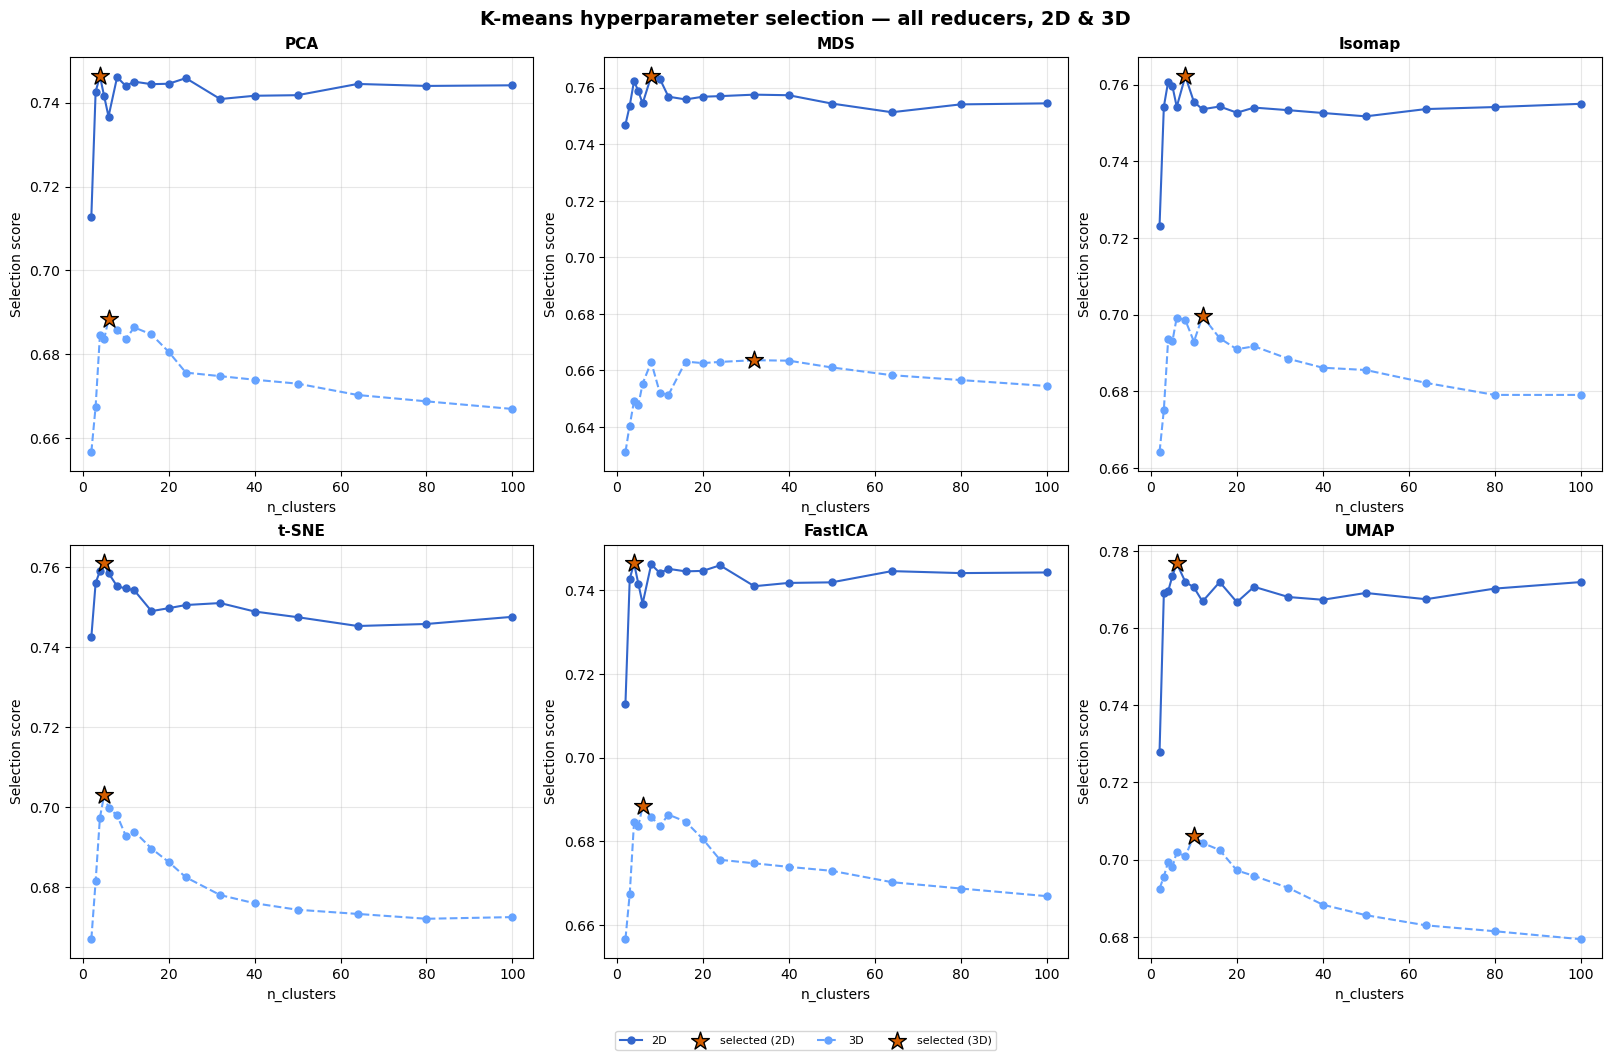

### K-means

**Hyperparameters swept:**
- `n_clusters`: number of centroids fit by Lloyd's algorithm

**Selection score:** 0.35 x silhouette + 0.20 x 1/(1+Davies-Bouldin) + 0.15 x Calinski-Harabasz/(Calinski-Harabasz+1000) + 0.15 x cluster-size balance (normalized entropy) + 0.15 x assigned-data fraction (1 - noise fraction). The highest-scoring combination wins, per reducer and per role.

,reduction_method,selection_role,n_components,n_clusters,noise_fraction,selection_score,n_clusters
0,fastica,display_2d,2,4,0.0,0.746329,4
1,fastica,display_3d,3,6,0.0,0.688380,6
2,isomap,display_2d,2,8,0.0,0.762212,8
3,isomap,display_3d,3,12,0.0,0.699544,12
4,mds,display_2d,2,8,0.0,0.764050,8
5,mds,display_3d,3,32,0.0,0.663639,32
6,pca,display_2d,2,4,0.0,0.746329,4
7,pca,display_3d,3,6,0.0,0.688380,6
8,tsne,display_2d,2,5,0.0,0.760910,5
9,tsne,display_3d,3,5,0.0,0.703122,5


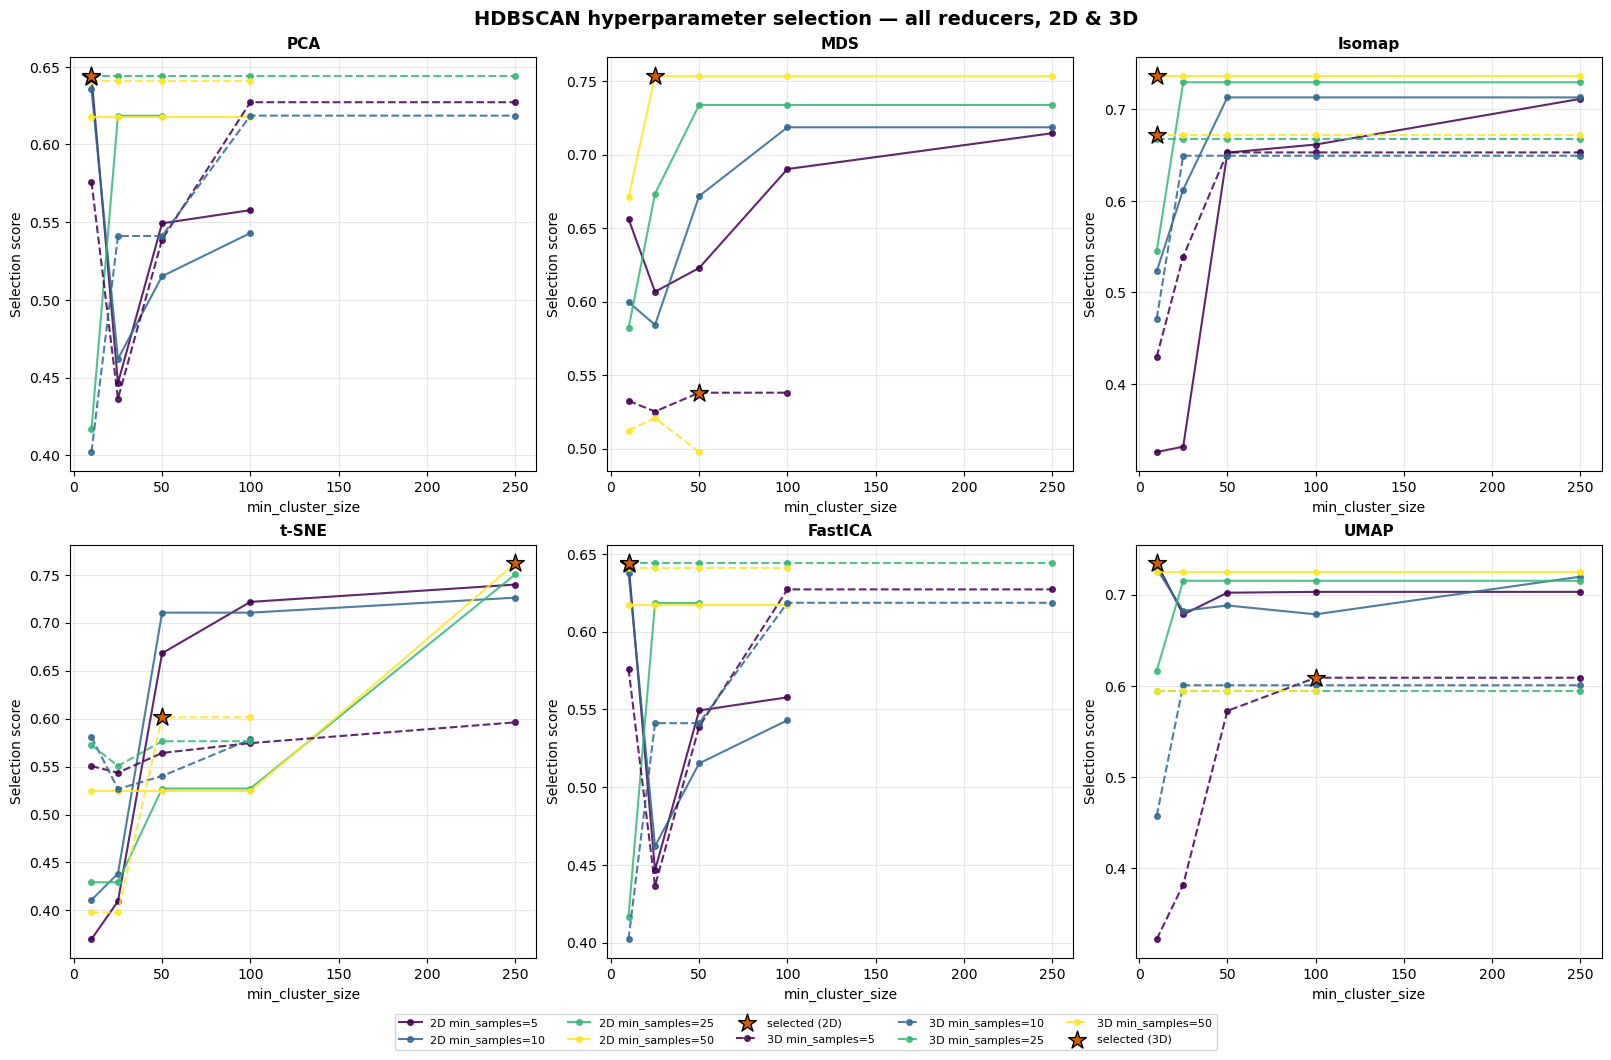

### HDBSCAN

**Hyperparameters swept:**
- `min_cluster_size`: minimum number of points HDBSCAN will call a cluster instead of noise
- `min_samples`: how conservative the density estimate is; higher values require denser cores and produce more noise

**Selection score:** 0.35 x silhouette + 0.20 x 1/(1+Davies-Bouldin) + 0.15 x Calinski-Harabasz/(Calinski-Harabasz+1000) + 0.15 x cluster-size balance (normalized entropy) + 0.15 x assigned-data fraction (1 - noise fraction). The highest-scoring combination wins, per reducer and per role.

,reduction_method,selection_role,n_components,n_clusters,noise_fraction,selection_score,min_cluster_size,min_samples
0,fastica,display_2d,2,40,0.468262,0.643608,10.0,5.0
1,fastica,display_3d,3,2,0.638184,0.643921,10.0,25.0
2,isomap,display_2d,2,2,0.408203,0.736370,10.0,50.0
3,isomap,display_3d,3,2,0.431152,0.672148,10.0,50.0
4,mds,display_2d,2,2,0.478516,0.753402,25.0,50.0
5,mds,display_3d,3,3,0.267090,0.538028,50.0,5.0
6,pca,display_2d,2,40,0.468262,0.643608,10.0,5.0
7,pca,display_3d,3,2,0.638184,0.643921,10.0,25.0
8,tsne,display_2d,2,2,0.747070,0.761869,250.0,50.0
9,tsne,display_3d,3,2,0.828613,0.601380,50.0,50.0


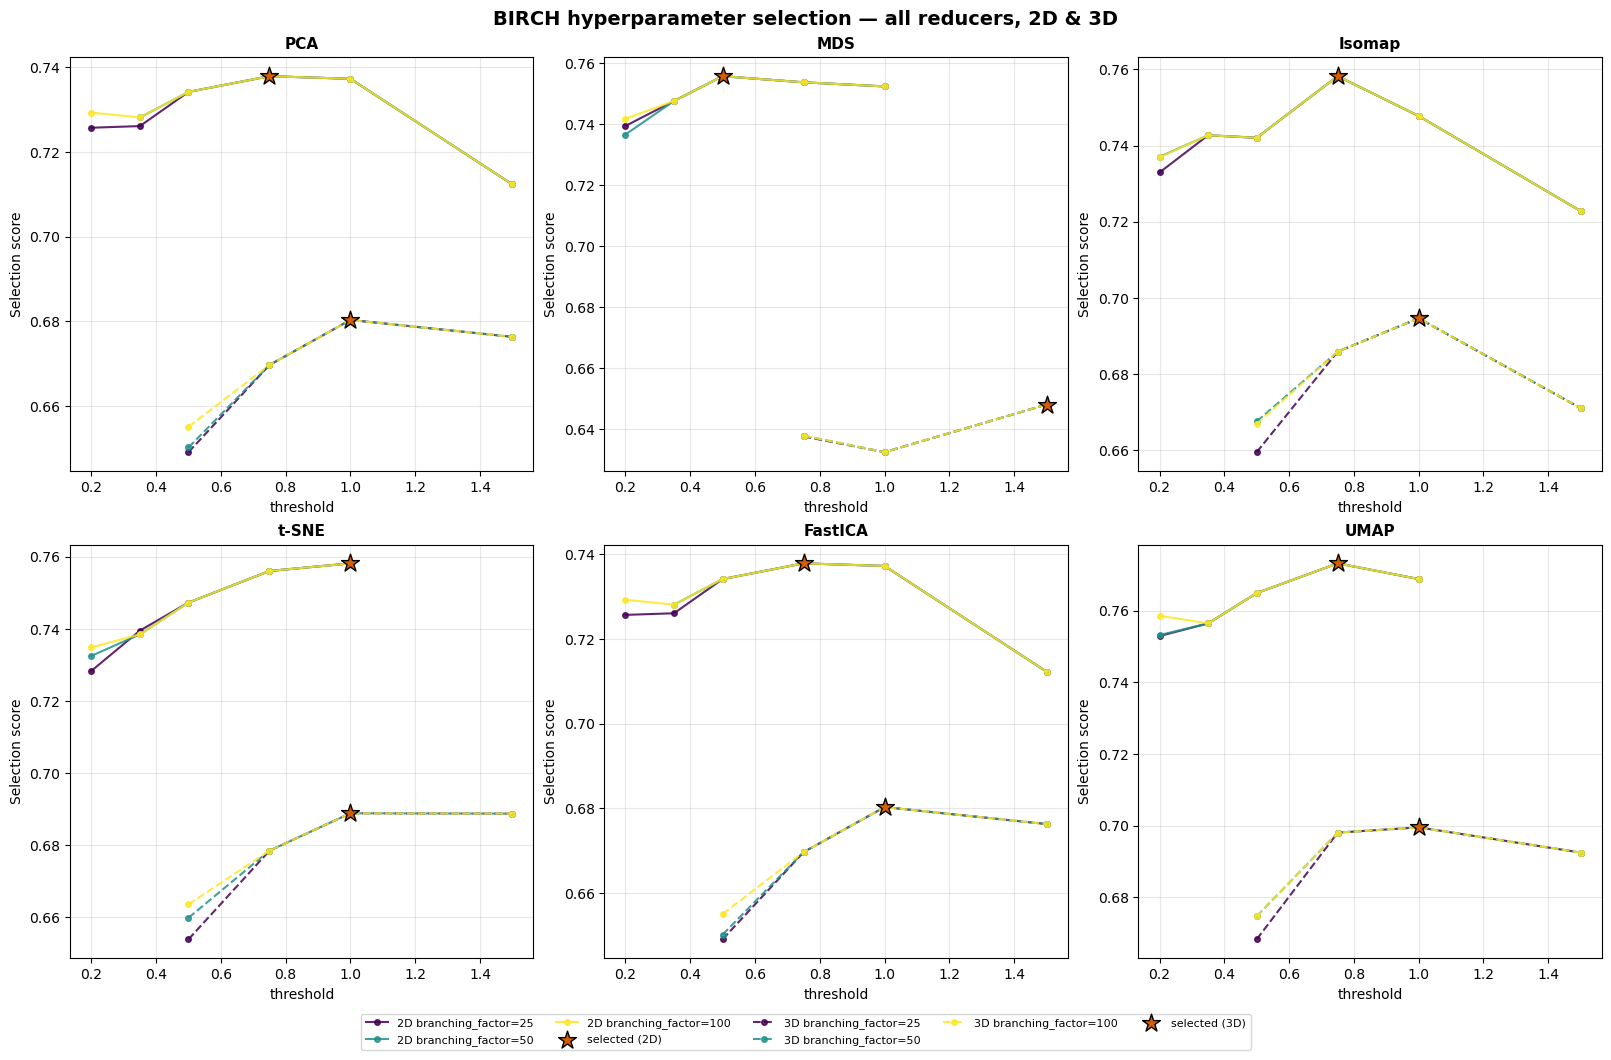

### BIRCH

**Hyperparameters swept:**
- `threshold`: max radius of a CF-subcluster before it is split; smaller values give more, tighter clusters
- `branching_factor`: how many children each node of BIRCH's CF-tree can hold before splitting

**Selection score:** 0.35 x silhouette + 0.20 x 1/(1+Davies-Bouldin) + 0.15 x Calinski-Harabasz/(Calinski-Harabasz+1000) + 0.15 x cluster-size balance (normalized entropy) + 0.15 x assigned-data fraction (1 - noise fraction). The highest-scoring combination wins, per reducer and per role.

,reduction_method,selection_role,n_components,n_clusters,noise_fraction,selection_score,threshold,branching_factor
0,fastica,display_2d,2,5,0.0,0.737865,0.75,25.0
1,fastica,display_3d,3,9,0.0,0.680307,1.00,25.0
2,isomap,display_2d,2,5,0.0,0.758224,0.75,25.0
3,isomap,display_3d,3,8,0.0,0.694601,1.00,25.0
4,mds,display_2d,2,11,0.0,0.755678,0.50,25.0
5,mds,display_3d,3,6,0.0,0.647942,1.50,25.0
6,pca,display_2d,2,5,0.0,0.737865,0.75,25.0
7,pca,display_3d,3,9,0.0,0.680307,1.00,25.0
8,tsne,display_2d,2,4,0.0,0.758160,1.00,25.0
9,tsne,display_3d,3,10,0.0,0.688864,1.00,25.0


In [4]:
CLUSTER_HYPERPARAM_MEANING = {
    "kmeans": {"n_clusters": "number of centroids fit by Lloyd's algorithm"},
    "hdbscan": {
        "min_cluster_size": "minimum number of points HDBSCAN will call a cluster instead of noise",
        "min_samples": "how conservative the density estimate is; higher values require denser cores and produce more noise",
    },
    "birch": {
        "threshold": "max radius of a CF-subcluster before it is split; smaller values give more, tighter clusters",
        "branching_factor": "how many children each node of BIRCH's CF-tree can hold before splitting",
    },
}
ROLE_STYLE = {"display_2d": {"linestyle": "-", "label": "2D"},
              "display_3d": {"linestyle": "--", "label": "3D"}}
SCORE_FORMULA = (
    "0.35 x silhouette + 0.20 x 1/(1+Davies-Bouldin) + "
    "0.15 x Calinski-Harabasz/(Calinski-Harabasz+1000) + "
    "0.15 x cluster-size balance (normalized entropy) + "
    "0.15 x assigned-data fraction (1 - noise fraction)"
)

for clusterer in CLUSTER_ORDER:
    hp_cols = list(CLUSTER_HYPERPARAM_MEANING[clusterer])
    primary = hp_cols[0]
    secondary = hp_cols[1] if len(hp_cols) > 1 else None

    fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor="white", constrained_layout=True)
    axes = axes.flatten()
    for idx, method in enumerate(REDUCTION_ORDER):
        ax = axes[idx]
        for role in ("display_2d", "display_3d"):
            reducer_row = selected_reducers[
                (selected_reducers["method"] == method)
                & selected_reducers["selection_role"].str.contains(role)
            ]
            if reducer_row.empty:
                continue
            reducer_tag = reducer_row.iloc[0]["tag"]
            sweep_subset = cluster_sweep[
                (cluster_sweep["reducer_tag"] == reducer_tag)
                & (cluster_sweep["method"] == clusterer)
                & np.isfinite(cluster_sweep["selection_score"])
            ]
            if sweep_subset.empty:
                continue
            style = ROLE_STYLE[role]
            if secondary is None:
                sub = sweep_subset.sort_values(primary)
                color = "#3366CC" if role == "display_2d" else "#66A3FF"
                ax.plot(sub[primary], sub["selection_score"], marker="o", markersize=5,
                        linestyle=style["linestyle"], color=color,
                        label=f"{style['label']}" if idx == 0 else None)
            else:
                secondary_values = sorted(sweep_subset[secondary].dropna().unique())
                cmap = matplotlib.colormaps["viridis"]
                denom = max(len(secondary_values) - 1, 1)
                for si, sval in enumerate(secondary_values):
                    sub = sweep_subset[sweep_subset[secondary] == sval].sort_values(primary)
                    if sub.empty:
                        continue
                    color = cmap(si / denom)
                    label = f"{style['label']} {secondary}={sval:g}" if idx == 0 else None
                    ax.plot(sub[primary], sub["selection_score"], marker="o", markersize=4,
                            linestyle=style["linestyle"], color=color, alpha=0.85, label=label)
            winner = selected_clusterings[
                (selected_clusterings["reduction_method"] == method)
                & (selected_clusterings["method"] == clusterer)
                & (selected_clusterings["selection_role"] == role)
            ]
            if not winner.empty:
                wrow = winner.iloc[0]
                ax.scatter([wrow[primary]], [wrow["selection_score"]], marker="*", s=180,
                           color="#D55E00", edgecolor="black", zorder=5,
                           label=f"selected ({style['label']})" if idx == 0 else None)
        ax.set_title(DISPLAY_NAMES[method], fontsize=11, fontweight="bold")
        ax.set_xlabel(primary)
        ax.set_ylabel("Selection score")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
               ncol=min(len(labels), 5), fontsize=8)
    fig.suptitle(f"{CLUSTER_DISPLAY[clusterer]} hyperparameter selection — all reducers, 2D & 3D",
                 fontsize=14, fontweight="bold")
    path = FIGURE_DIR / f"cluster_selection_{clusterer}.png"
    fig.savefig(path, dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()

    lines = [f"### {CLUSTER_DISPLAY[clusterer]}", "", "**Hyperparameters swept:**"]
    for col, meaning in CLUSTER_HYPERPARAM_MEANING[clusterer].items():
        lines.append(f"- `{col}`: {meaning}")
    lines.append("")
    lines.append(f"**Selection score:** {SCORE_FORMULA}. The highest-scoring combination wins, per reducer and per role.")
    display(Markdown("\n".join(lines)))

    winners = selected_clusterings[
        (selected_clusterings["method"] == clusterer)
        & selected_clusterings["selection_role"].isin(["display_2d", "display_3d"])
    ][["reduction_method", "selection_role", "n_components", "n_clusters", "noise_fraction",
       "selection_score"] + hp_cols].sort_values(["reduction_method", "selection_role"])
    display(winners.reset_index(drop=True))


## Section 3: 2D scatterplots (18 figures: 6 reducers x 3 clusterers)

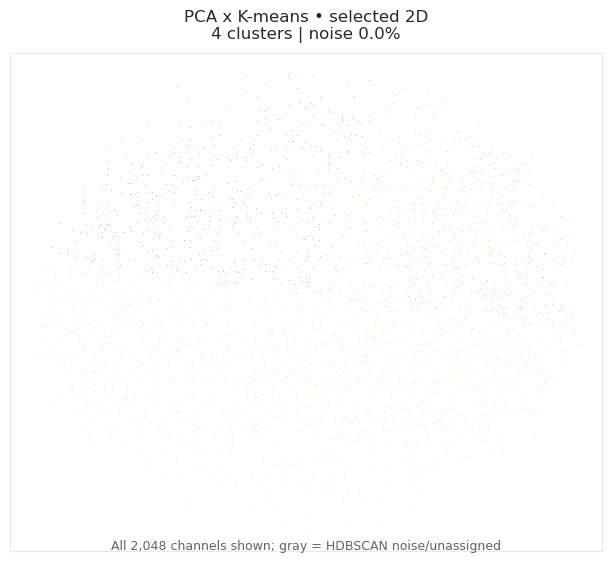

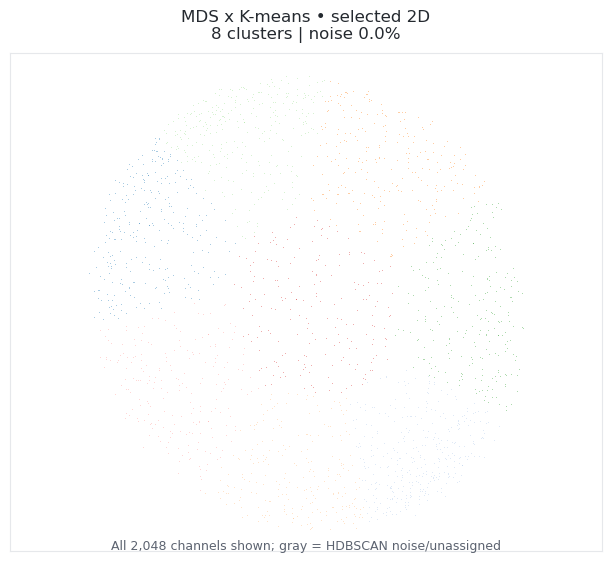

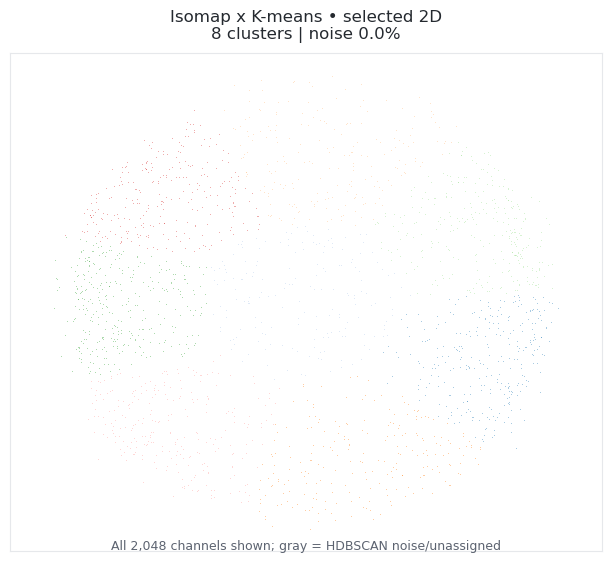

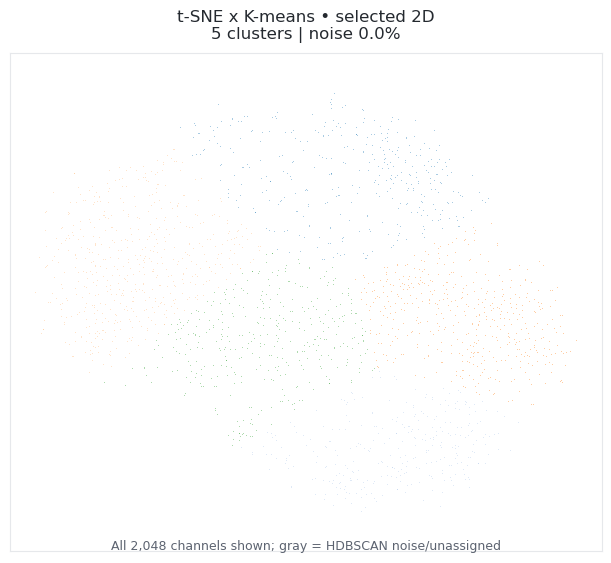

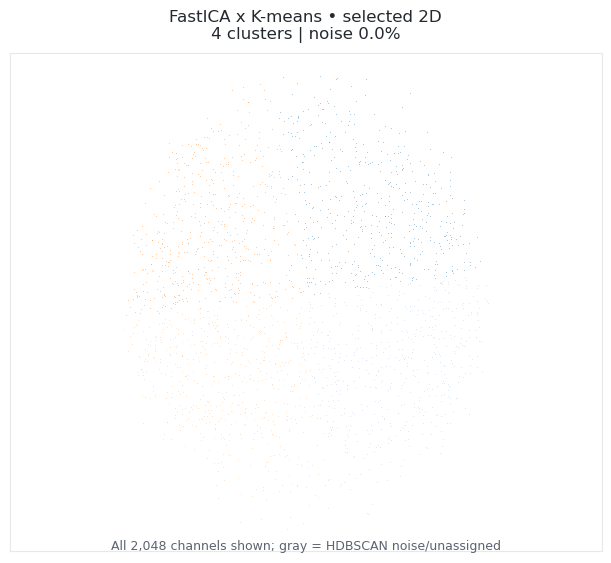

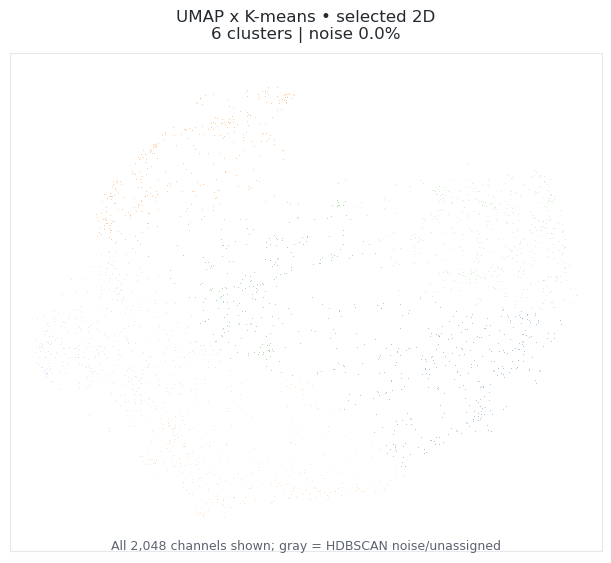

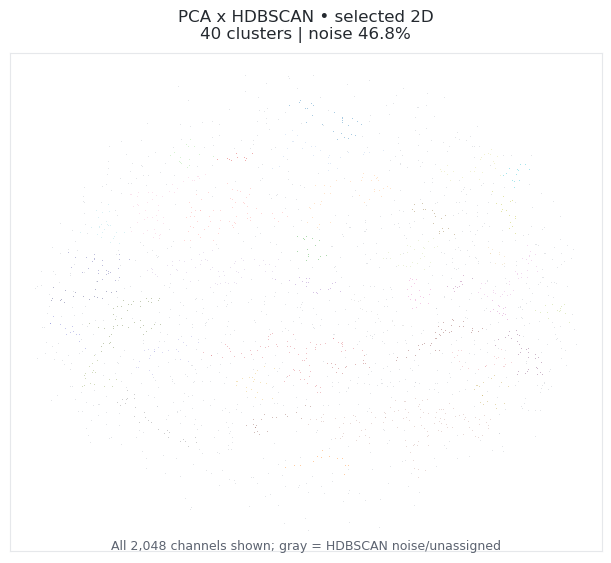

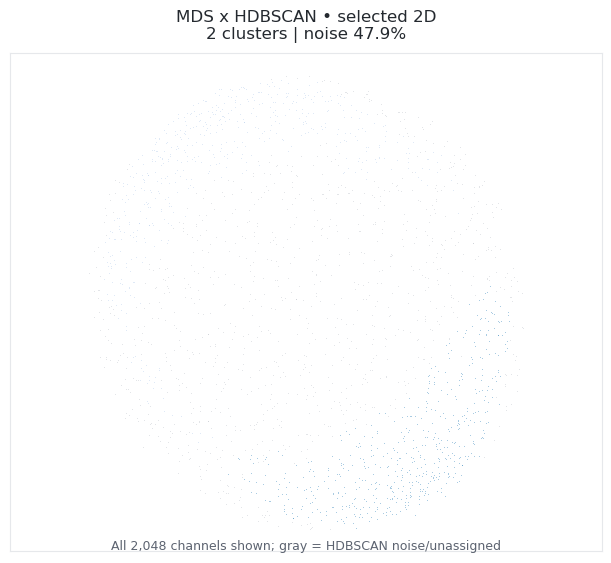

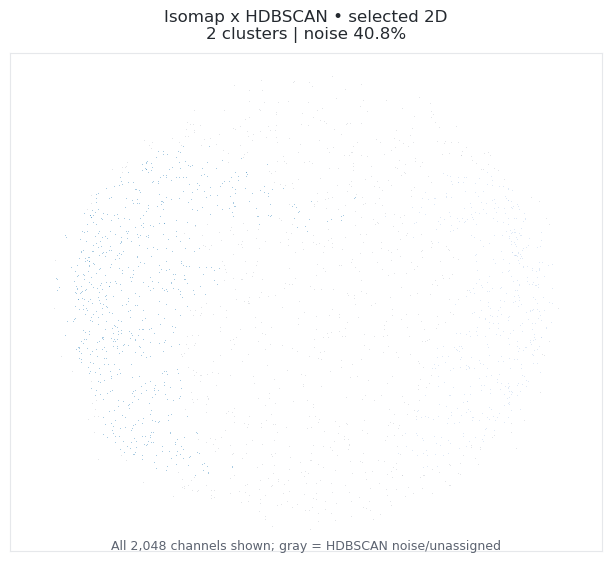

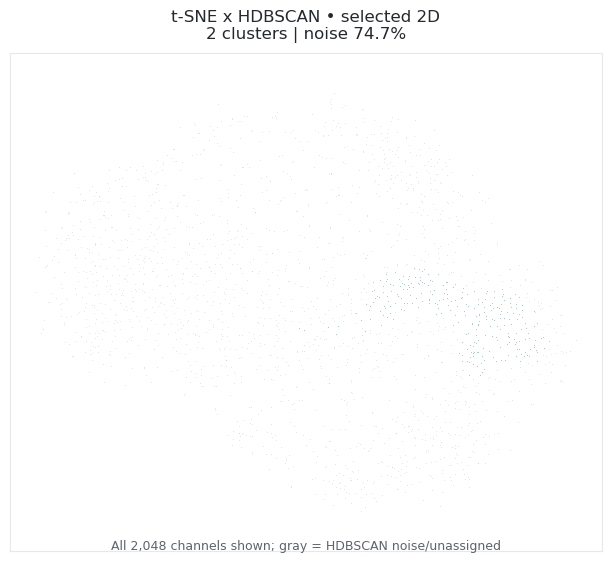

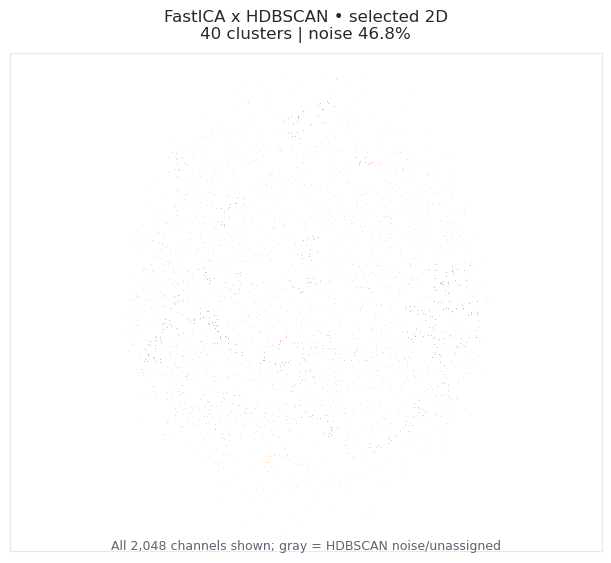

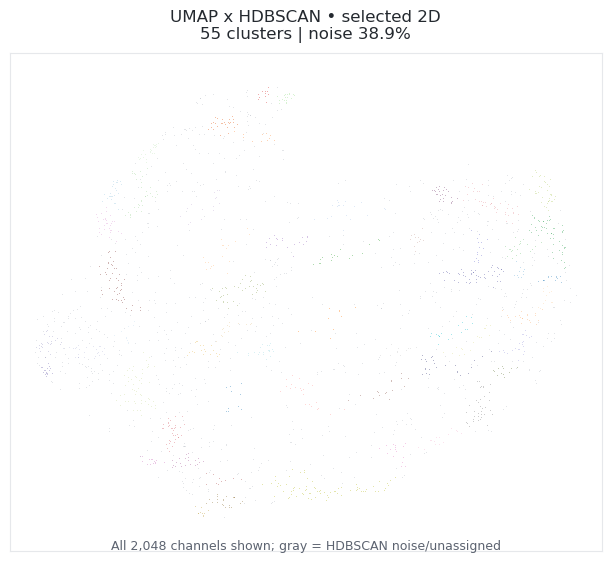

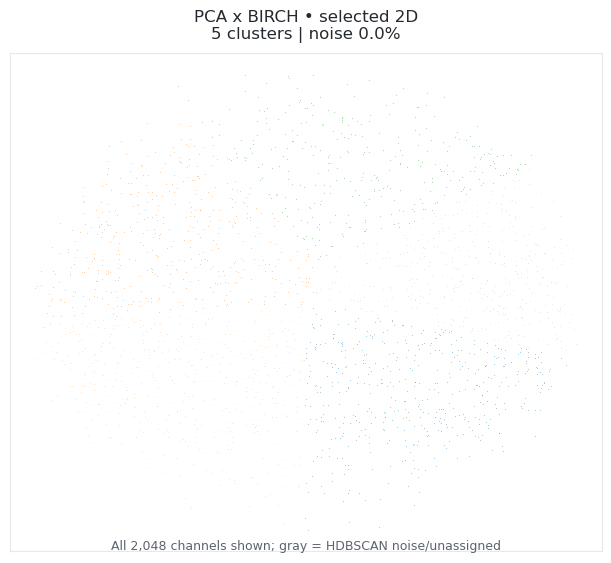

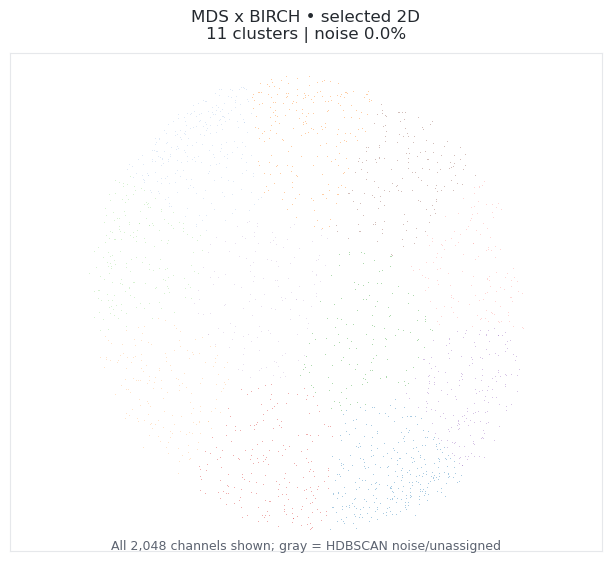

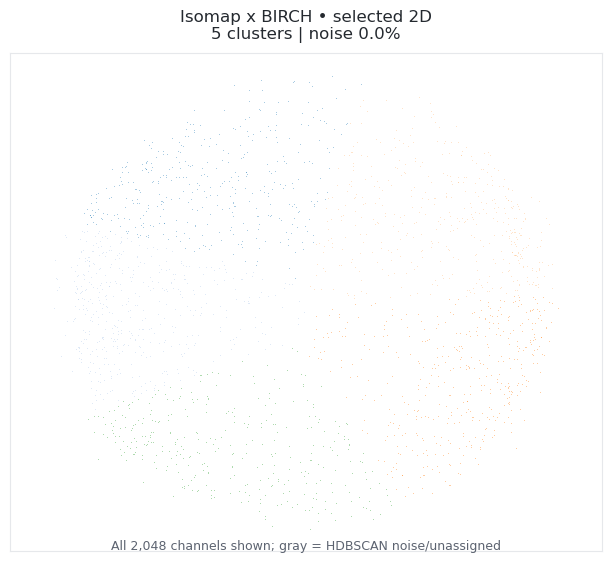

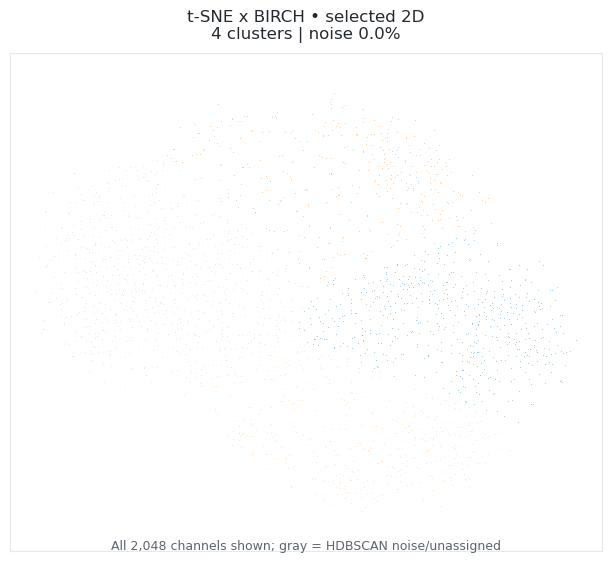

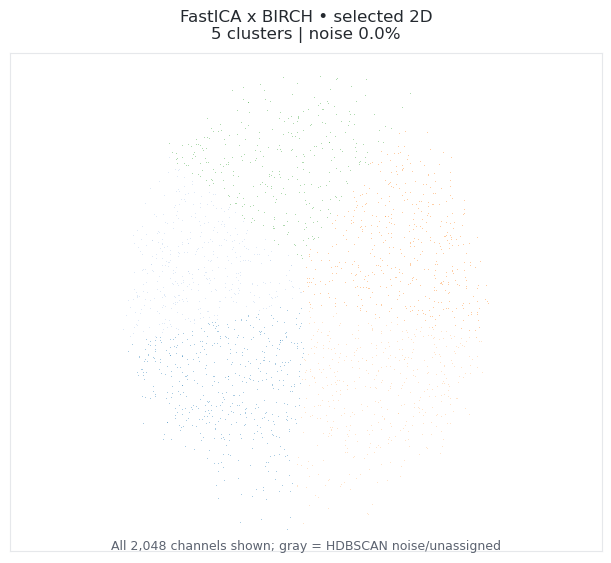

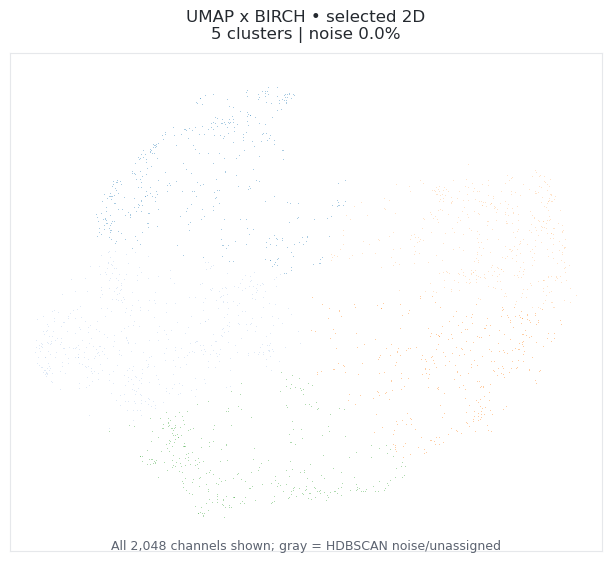

In [5]:
def _get_distinct_colormap(n_colors: int):
    import colorsys
    colors = []
    for cmap_name in ("tab20", "tab20b", "tab20c"):
        cmap = matplotlib.colormaps[cmap_name]
        for i in range(cmap.N):
            if len(colors) >= n_colors:
                return colors
            r, g, b, _ = cmap(i / cmap.N)
            colors.append((r, g, b, 1.0))
    for i in range(n_colors - len(colors)):
        hue = (i * 0.618033988749895) % 1.0
        r, g, b = colorsys.hsv_to_rgb(hue, 0.7, 0.9)
        colors.append((r, g, b, 1.0))
    return colors

NOISE_COLOR = "#B8BDC5"
INK = "#24292F"
GRID = "#E6E8EB"

def cluster_color(raw_label, max_label):
    if raw_label == -1:
        return NOISE_COLOR
    distinct_colors = _get_distinct_colormap(max_label + 1)
    return distinct_colors[int(raw_label)]

def find_map_record(reducer_tag, clusterer):
    return next(
        (row for row in map_manifest
         if row["reducer_tag"] == reducer_tag and row["cluster_method"] == clusterer),
        None,
    )

def setup_paths(reduction, role, clusterer):
    reducer = selected_reducers[
        (selected_reducers["method"] == reduction)
        & selected_reducers["selection_role"].str.contains(role)
    ].iloc[0]
    record = find_map_record(reducer["tag"], clusterer)
    if record is None:
        return reducer, None, None, None
    report_path = Path(record["report"])
    report = json.loads(report_path.read_text())
    return reducer, Path(reducer["embedding"]), report_path.parent / "channel_labels.npy", report

def draw_clusters(ax, coordinates, labels, dimensions):
    # All channels are plotted. Clusters are drawn first, noise last on top —
    # for HDBSCAN, drawing noise underneath the majority of assigned points made it
    # fully invisible regardless of alpha. Drawing it last, small and low-alpha, makes
    # it read as light gray background texture without swamping the cluster structure.
    # Rasterized markers keep multi-thousand-point figures legible and the saved PNGs
    # a reasonable size.
    max_label = int(np.max(labels))
    ordered_labels = sorted(np.unique(labels), key=lambda value: (value == -1, value))
    for raw_label in ordered_labels:
        mask = labels == raw_label
        color = cluster_color(raw_label, max_label)
        alpha = 0.35 if raw_label == -1 else 0.28
        size = 0.4 if raw_label == -1 else 0.5
        if dimensions == 2:
            ax.scatter(coordinates[mask, 0], coordinates[mask, 1],
                       s=size, c=[color], alpha=alpha, linewidths=0, rasterized=True)
        else:
            ax.scatter(coordinates[mask, 0], coordinates[mask, 1],
                       coordinates[mask, 2], s=size, c=[color], alpha=alpha,
                       linewidths=0, depthshade=False, rasterized=True)

def plot_single_reducer(reduction, clusterer, role, plot_dimensions):
    projection = {"projection": "3d"} if plot_dimensions == 3 else None
    figure = plt.figure(figsize=(6, 5.5), facecolor="white", constrained_layout=True)
    ax = figure.add_subplot(1, 1, 1, **(projection or {}))

    reducer, embedding_path, labels_path, report = setup_paths(reduction, role, clusterer)
    coordinates = np.load(embedding_path, mmap_mode="r")
    labels = np.load(labels_path, mmap_mode="r")
    draw_clusters(ax, coordinates, labels, plot_dimensions)

    actual_dimensions = int(reducer["n_components"])
    ax.set_title(
        f"{DISPLAY_NAMES[reduction]} x {CLUSTER_DISPLAY[clusterer]} • selected {actual_dimensions}D\n"
        f"{report['n_clusters']} clusters | noise {report['noise_fraction']:.1%}",
        color=INK, fontsize=12, pad=10,
    )
    ax.set_xticks([]); ax.set_yticks([])
    if plot_dimensions == 3:
        ax.set_zticks([])
        ax.view_init(elev=22, azim=-58)
        ax.set_box_aspect((1, 1, 0.85))
        ax.grid(False)
    else:
        ax.set_aspect("equal", adjustable="datalim")
    for spine in getattr(ax, "spines", {}).values():
        spine.set_color(GRID)

    figure.text(
        0.5, 0.01,
        f"All {n_channels:,} channels shown; gray = HDBSCAN noise/unassigned",
        ha="center", fontsize=9, color="#5C6370",
    )

    file_role = {"display_2d": "2d", "display_3d": "3d"}[role]
    output_path = FIGURE_DIR / f"scatterplot_{reduction}_{clusterer}_{file_role}.png"
    figure.savefig(output_path, dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()
    return output_path

figure_records = []
for clusterer in CLUSTER_ORDER:
    for reduction in REDUCTION_ORDER:
        path = plot_single_reducer(reduction, clusterer, "display_2d", 2)
        figure_records.append((clusterer, reduction, "display_2d", path))


## Section 4: 3D scatterplots (18 figures: 6 reducers x 3 clusterers)

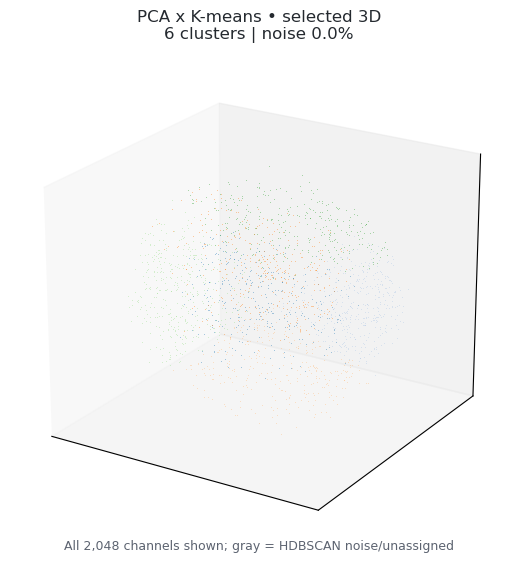

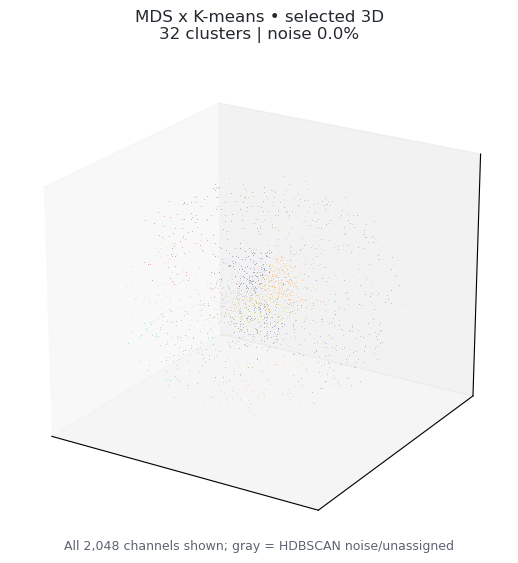

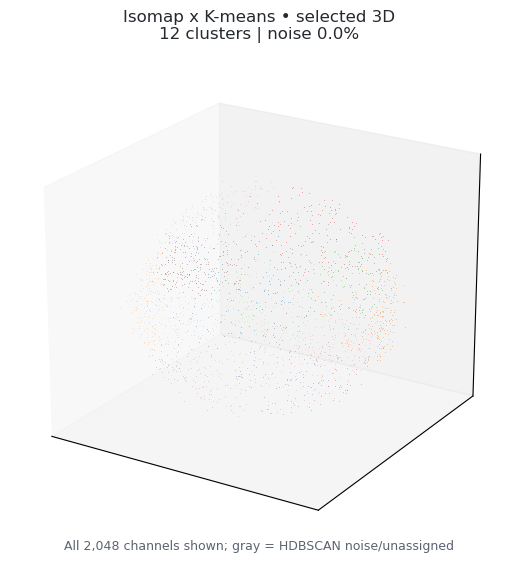

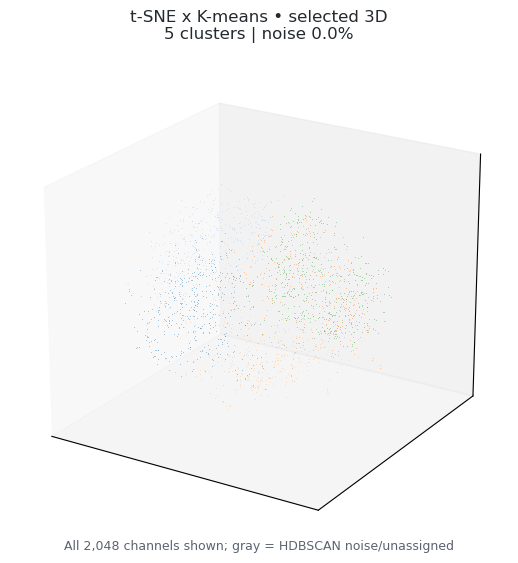

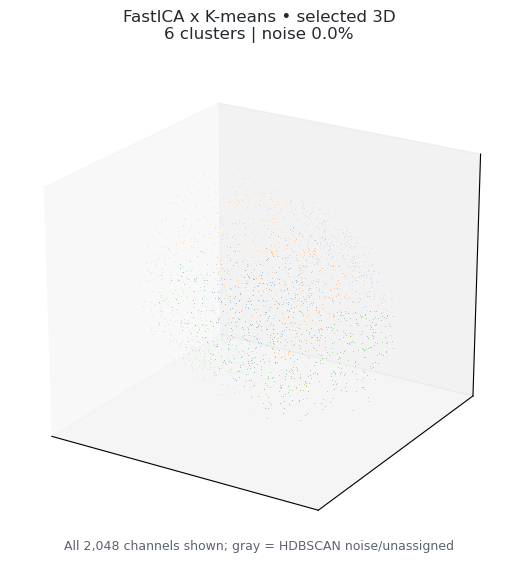

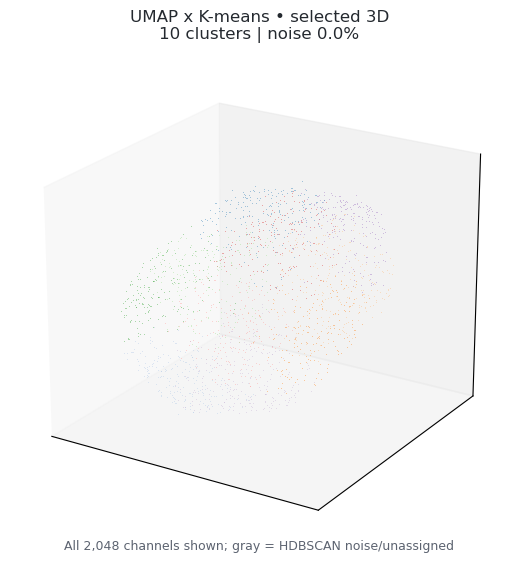

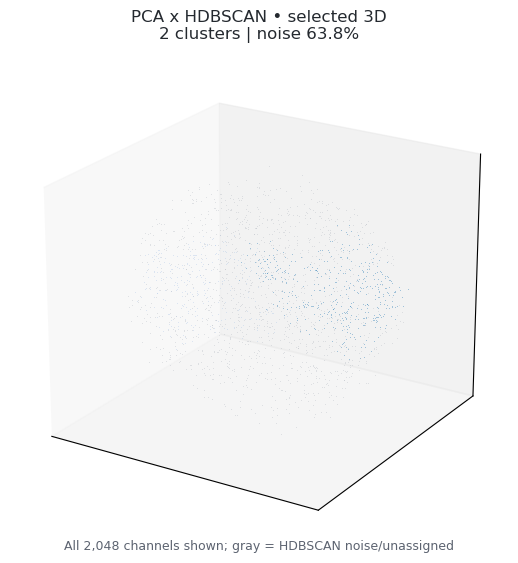

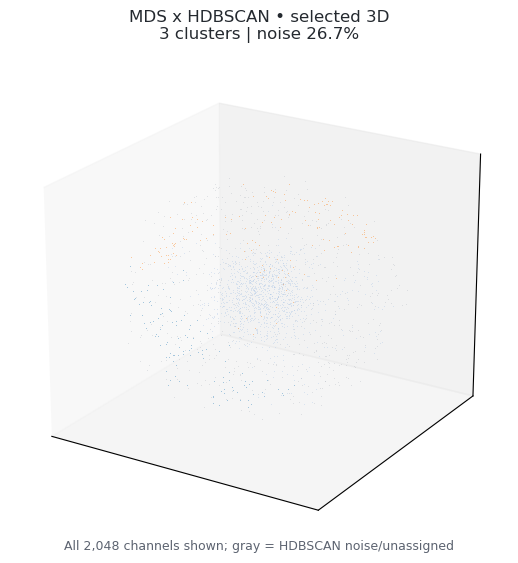

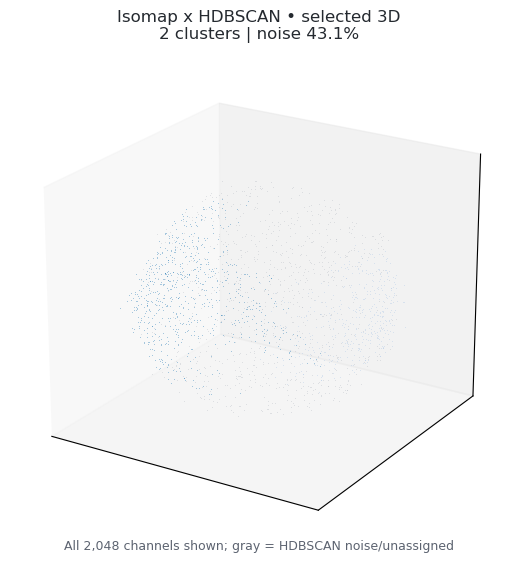

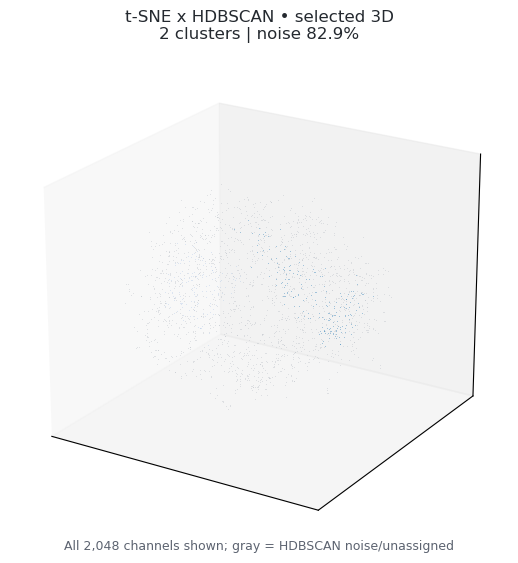

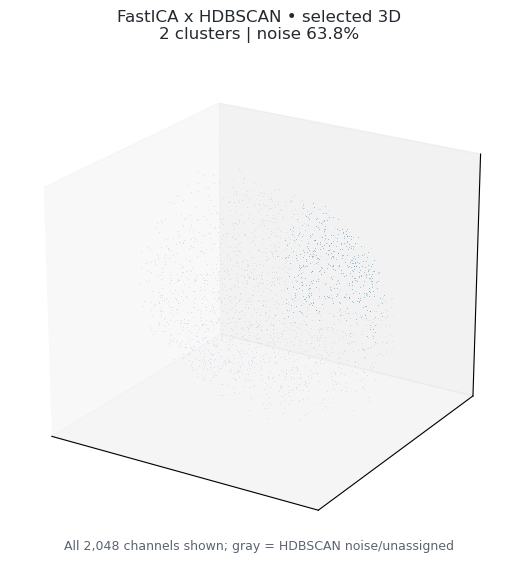

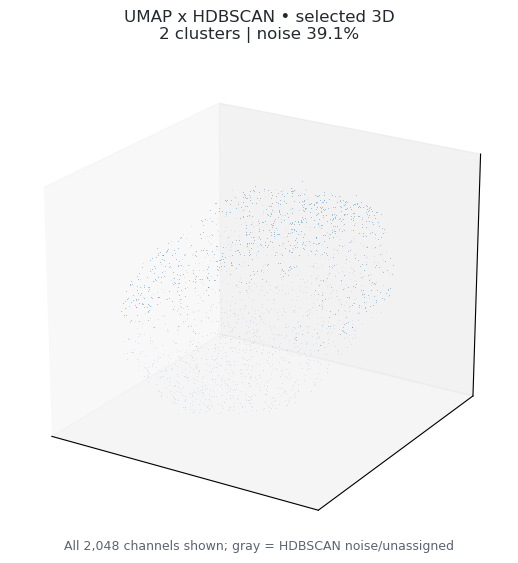

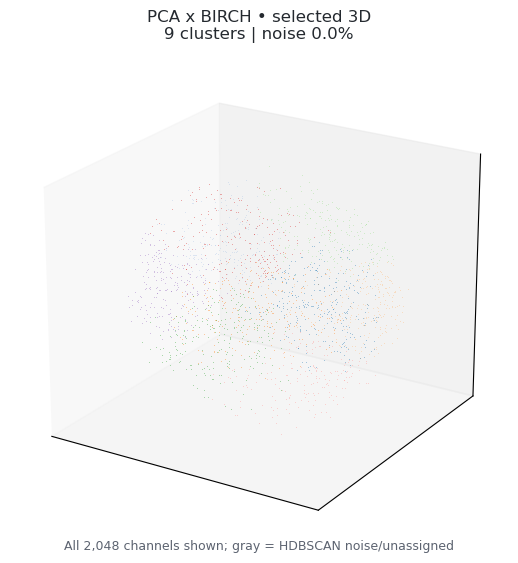

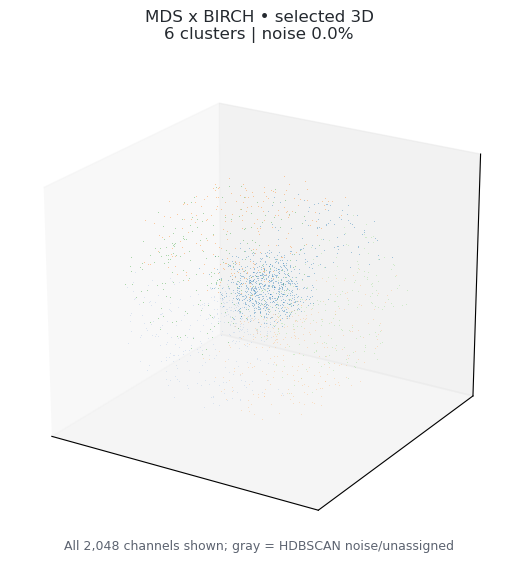

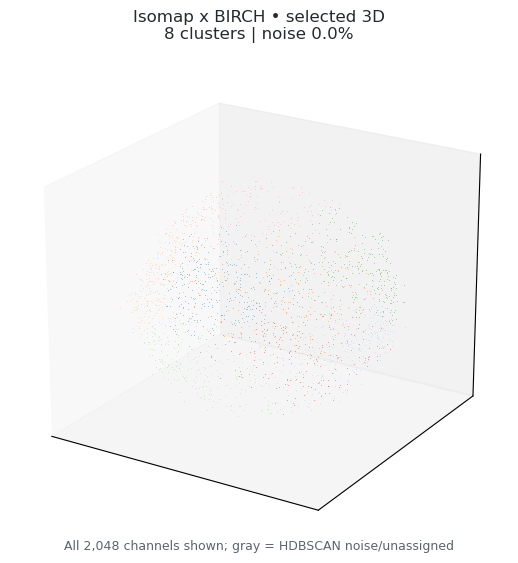

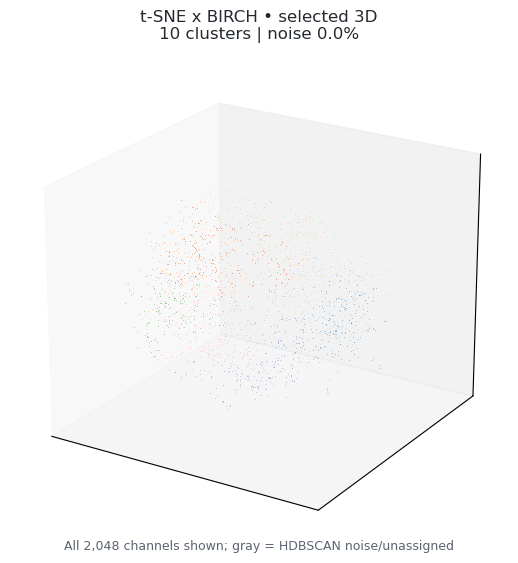

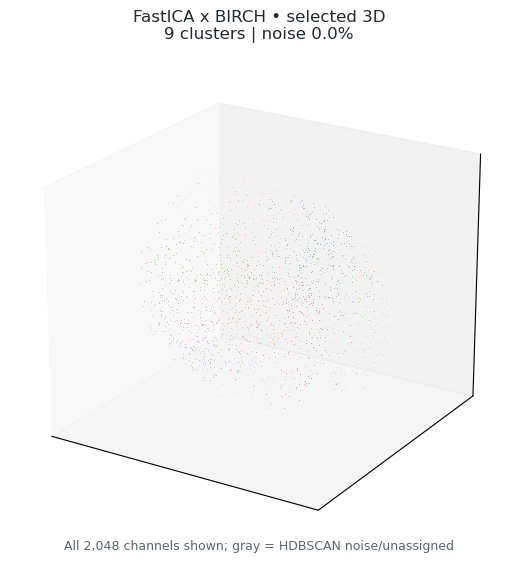

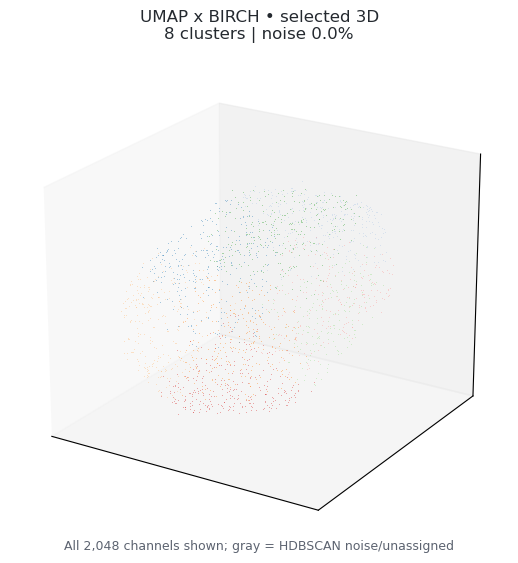

In [6]:
for clusterer in CLUSTER_ORDER:
    for reduction in REDUCTION_ORDER:
        path = plot_single_reducer(reduction, clusterer, "display_3d", 3)
        figure_records.append((clusterer, reduction, "display_3d", path))


## Section 5: does the visible clustering survive at full latent dimensionality?

Every scatterplot in Sections 3-4 shows cluster labels that were *found by clustering the
2-D or 3-D display embedding* — the dimensionality chosen purely so the geometry could be
plotted. Section 2's sweep also fits K-means/HDBSCAN/BIRCH on each reducer's `latent_best`
embedding, at its own elbow-selected native dimensionality (Section 1: typically 4-12
components here, never 2 or 3 — see the table in Cell "Data & setup" and Section 1's
per-reducer captions) — but until now those labels were never rendered as their own
picture, because a 4-12 dimensional point cloud has no direct picture to draw.

Below, for every (reduction method, clustering algorithm) pair where **both** a display-
space and a `latent_best` clustering succeeded, we plot the *same* display 2-D/3-D
coordinates twice, side by side:

- **Left panel — display-space clustering:** identical to the corresponding panel in
  Sections 3-4. Cluster labels were both *found* and *shown* in the 2-D/3-D embedding.
- **Right panel — latent-best clustering, projected:** cluster labels were *found* in the
  reducer's higher-dimensional `latent_best` embedding, then merely plotted at the display
  embedding's 2-D/3-D coordinates (same coordinates as the left panel) for visual
  comparison. Only the *coloring* differs between the panels; the point positions are
  identical within a pair.

**Which one should a reader trust?** The `latent_best` labels are the more defensible
clustering of the two: they were fit where more of the reduction's structure survives —
the dimensionality each method's own reconstruction/stress/geometry criterion selected via
a diminishing-returns elbow (Section 1) — rather than in a 2-3-D projection chosen only
because it can be plotted. The **adjusted Rand index (ARI)** printed on each right panel,
and tabulated below, quantifies how much the two labelings agree (1.0 = identical
partitions up to relabeling, ~0.0 = agreement no better than chance; HDBSCAN's noise label
is treated as its own group like any other, not specially excluded). A low ARI means the
grouping visible in Sections 3-4 is largely an artifact of compressing to 2-3 dimensions
for display and does not hold up once the extra latent dimensions are kept in; a high ARI
means the display-space picture is a reasonable stand-in for the fuller clustering. Use the
display-space panels (and Sections 3-4) for *looking* at geometry; use the `latent_best`
panels — and the ARI table below — for judging whether that geometry is *real* structure.


In [7]:
def get_latent_best(reduction, clusterer):
    '''Return (latent_reducer_row, labels array) for a method's latent_best
    clustering under `clusterer`, or (None, None) if that combination has no valid
    full-channel-set clustering (see the missing-combination list printed in setup).
    '''
    latent_rows = selected_reducers[
        (selected_reducers["method"] == reduction)
        & selected_reducers["selection_role"].str.contains("latent_best")
    ]
    if latent_rows.empty:
        return None, None
    latent_reducer = latent_rows.iloc[0]
    record = find_map_record(latent_reducer["tag"], clusterer)
    if record is None:
        return None, None
    labels = np.load(Path(record["report"]).parent / "channel_labels.npy", mmap_mode="r")
    return latent_reducer, np.asarray(labels)

def plot_comparison(reduction, clusterer, role, plot_dimensions):
    display_reducer, embedding_path, labels_path, display_report = setup_paths(reduction, role, clusterer)
    if labels_path is None:
        return None, None  # display-space clustering itself missing (not expected for display_2d/3d)
    latent_reducer, latent_labels = get_latent_best(reduction, clusterer)
    if latent_labels is None:
        return None, None  # latent_best clustering missing for this (method, clusterer)

    display_coords = np.load(embedding_path, mmap_mode="r")
    display_labels = np.asarray(np.load(labels_path, mmap_mode="r"))
    ari = adjusted_rand_score(display_labels, latent_labels)

    projection = {"projection": "3d"} if plot_dimensions == 3 else None
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), facecolor="white",
                              subplot_kw=projection, constrained_layout=True)
    draw_clusters(axes[0], display_coords, display_labels, plot_dimensions)
    draw_clusters(axes[1], display_coords, latent_labels, plot_dimensions)

    display_dim = int(display_reducer["n_components"])
    latent_dim = int(latent_reducer["n_components"])
    axes[0].set_title(
        f"display-space clustering ({display_dim}D)\n"
        f"{display_report['n_clusters']} clusters | noise {display_report['noise_fraction']:.1%}",
        color=INK, fontsize=11,
    )
    axes[1].set_title(
        f"latent-best clustering ({latent_dim}D), projected\nARI vs. display = {ari:.3f}",
        color=INK, fontsize=11,
    )
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
        if plot_dimensions == 3:
            ax.set_zticks([])
            ax.view_init(elev=22, azim=-58)
            ax.set_box_aspect((1, 1, 0.85))
            ax.grid(False)
        else:
            ax.set_aspect("equal", adjustable="datalim")
        for spine in getattr(ax, "spines", {}).values():
            spine.set_color(GRID)
    fig.suptitle(
        f"{DISPLAY_NAMES[reduction]} x {CLUSTER_DISPLAY[clusterer]}: display-space vs. "
        f"latent-best clustering ({plot_dimensions}D display coordinates)",
        fontsize=12.5, fontweight="bold",
    )
    fig.text(0.5, 0.01, f"All {n_channels:,} channels shown; gray = HDBSCAN noise/unassigned",
              ha="center", fontsize=9, color="#5C6370")

    file_role = {"display_2d": "2d", "display_3d": "3d"}[role]
    output_path = FIGURE_DIR / f"comparison_{reduction}_{clusterer}_{file_role}.png"
    fig.savefig(output_path, dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()
    return output_path, ari

comparison_records = []
ari_records = []
skipped_comparisons = []


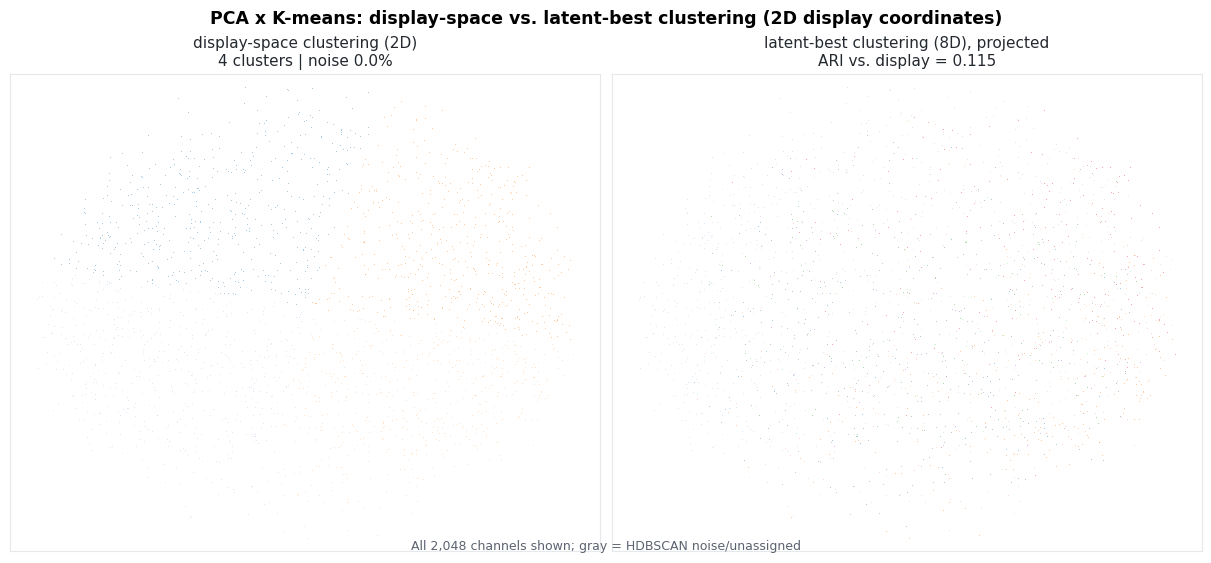

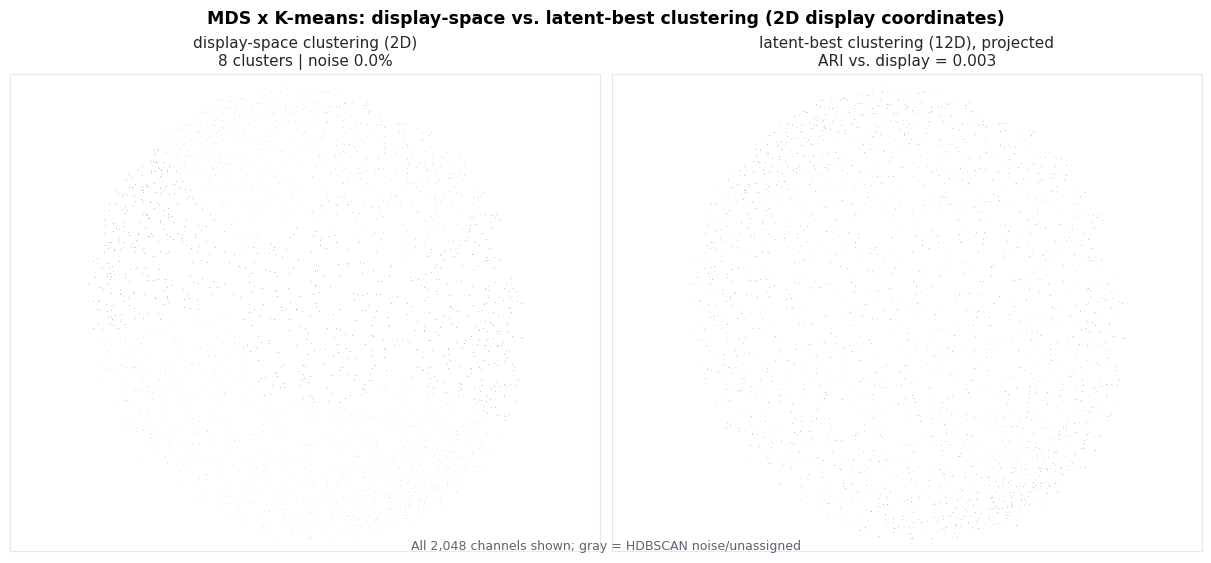

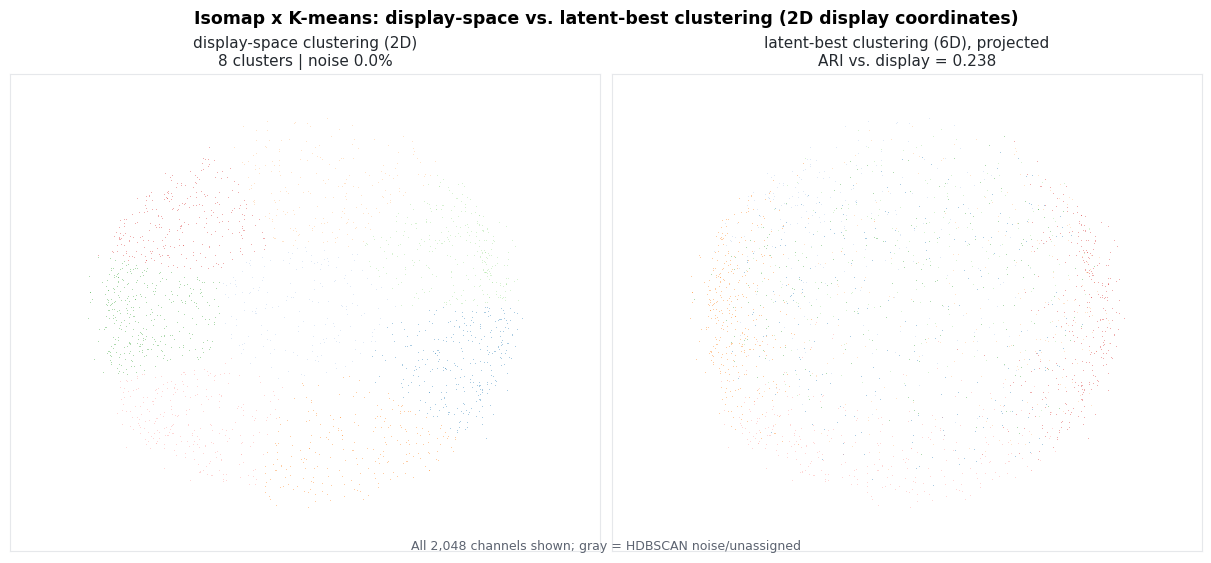

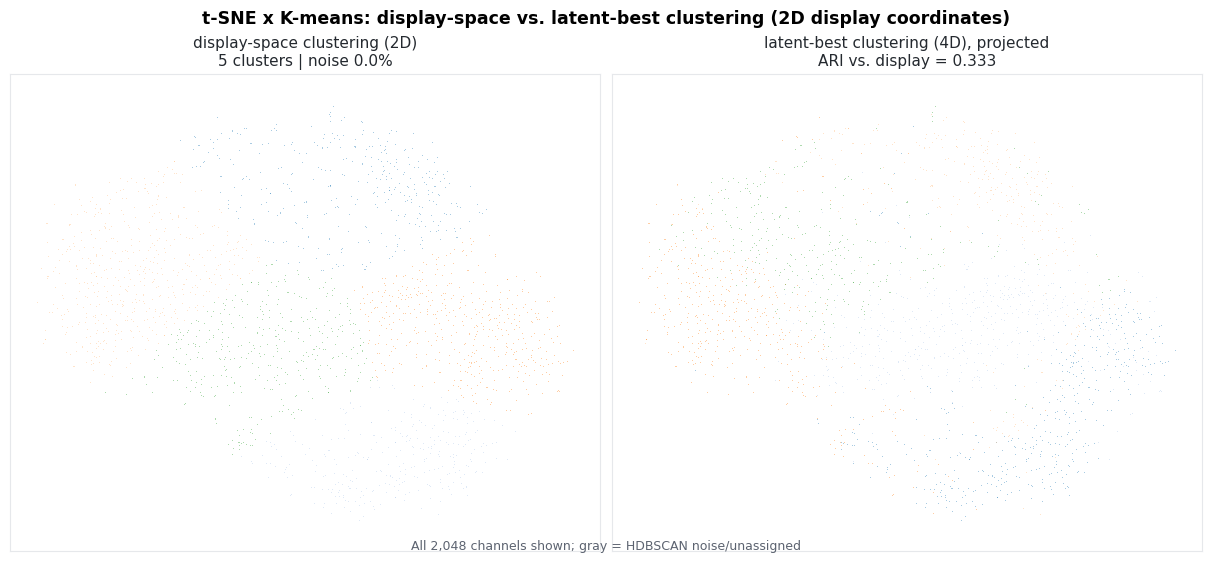

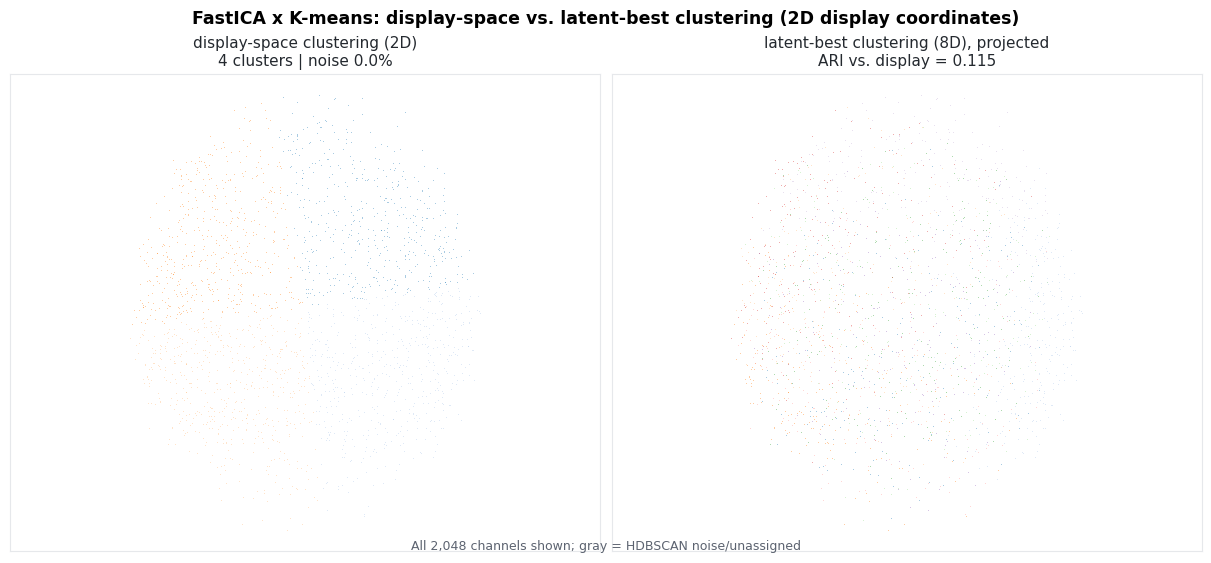

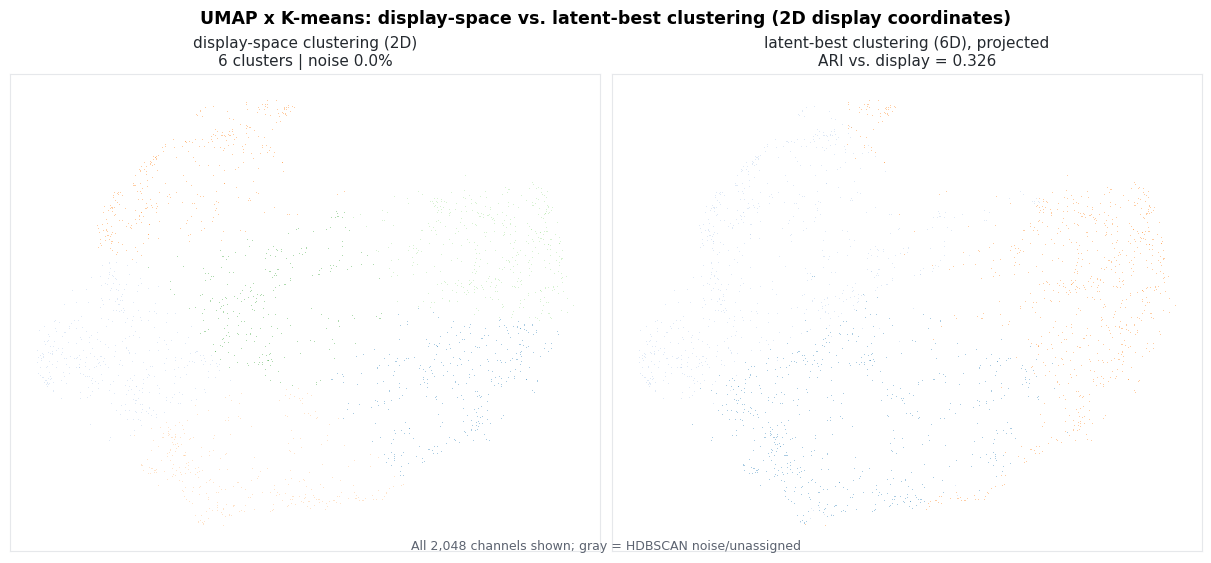

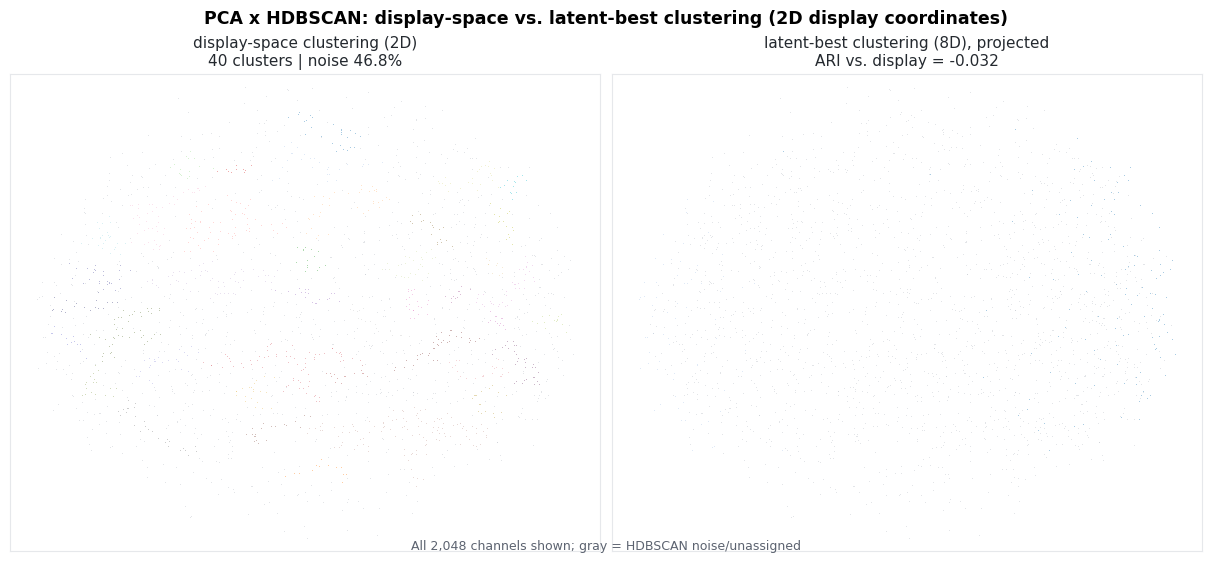

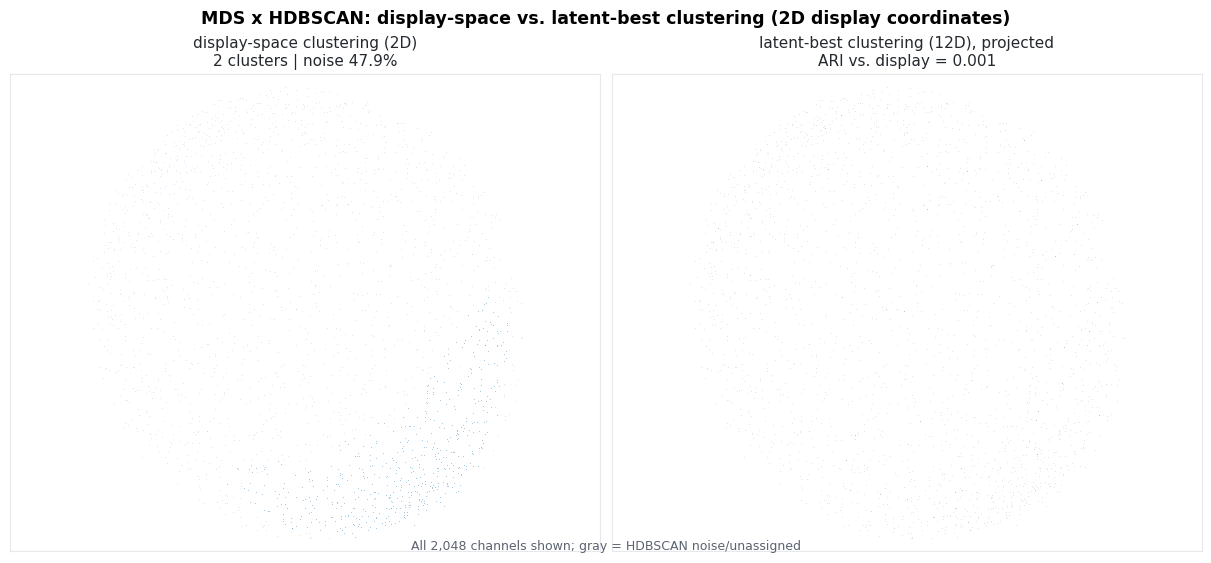

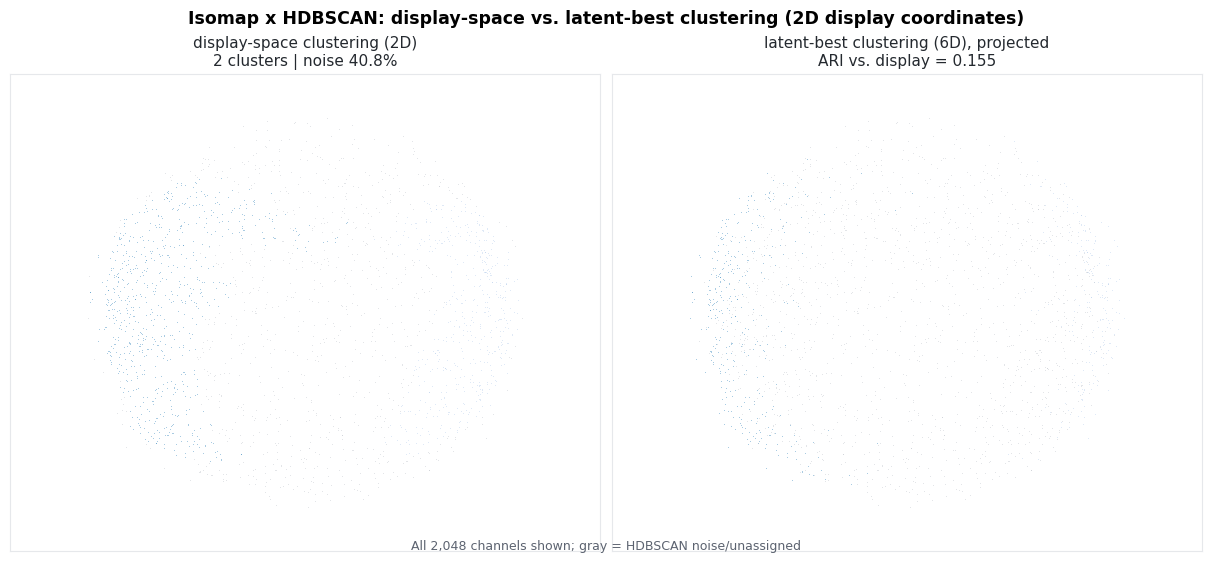

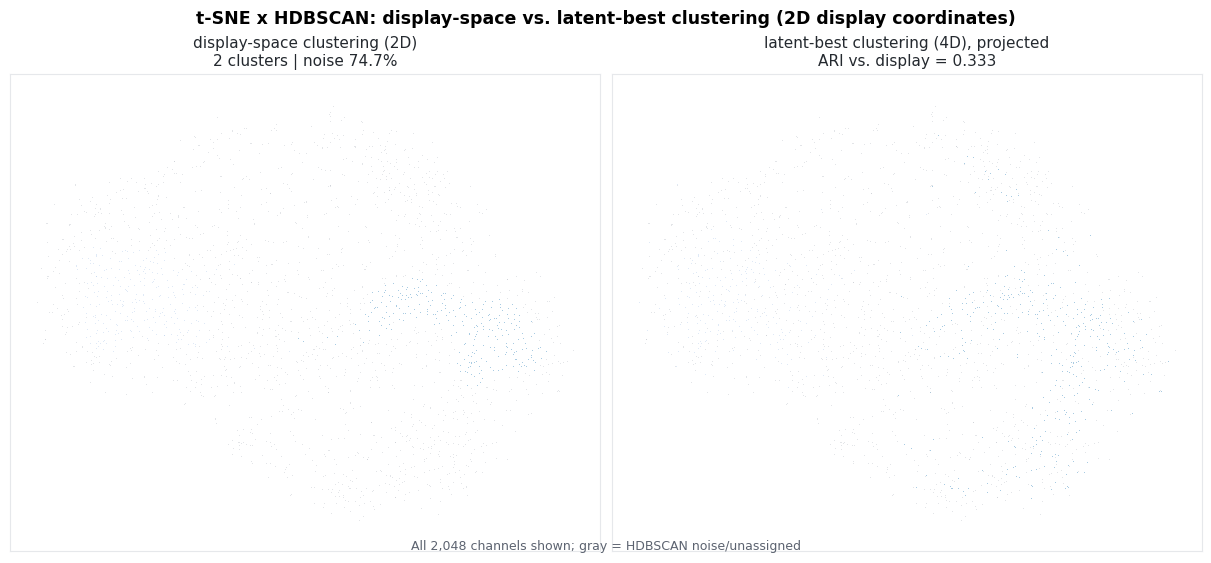

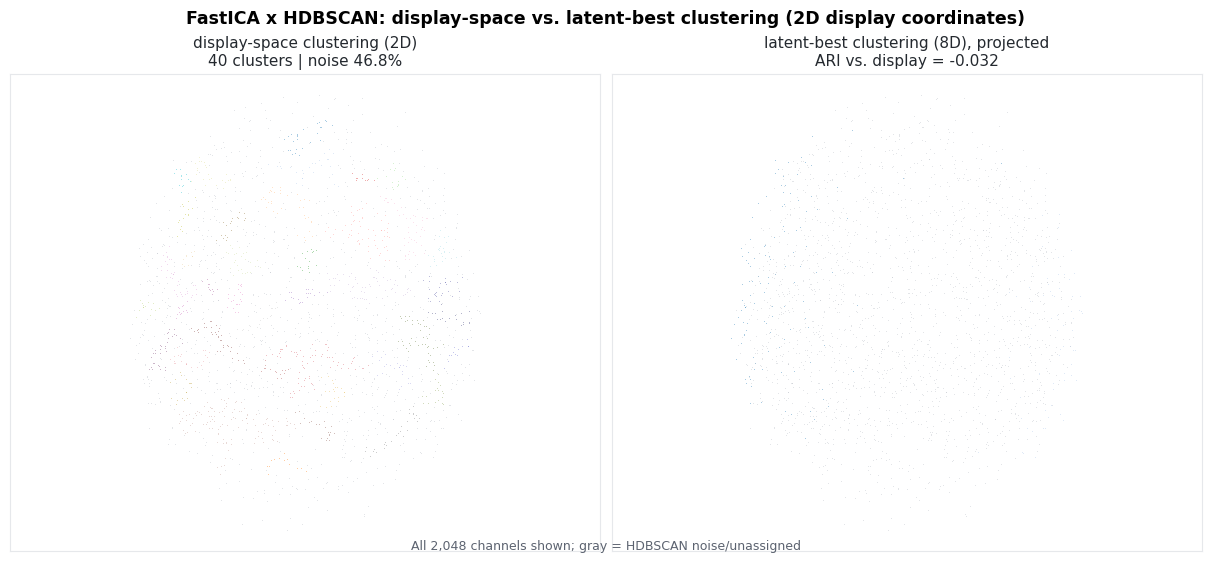

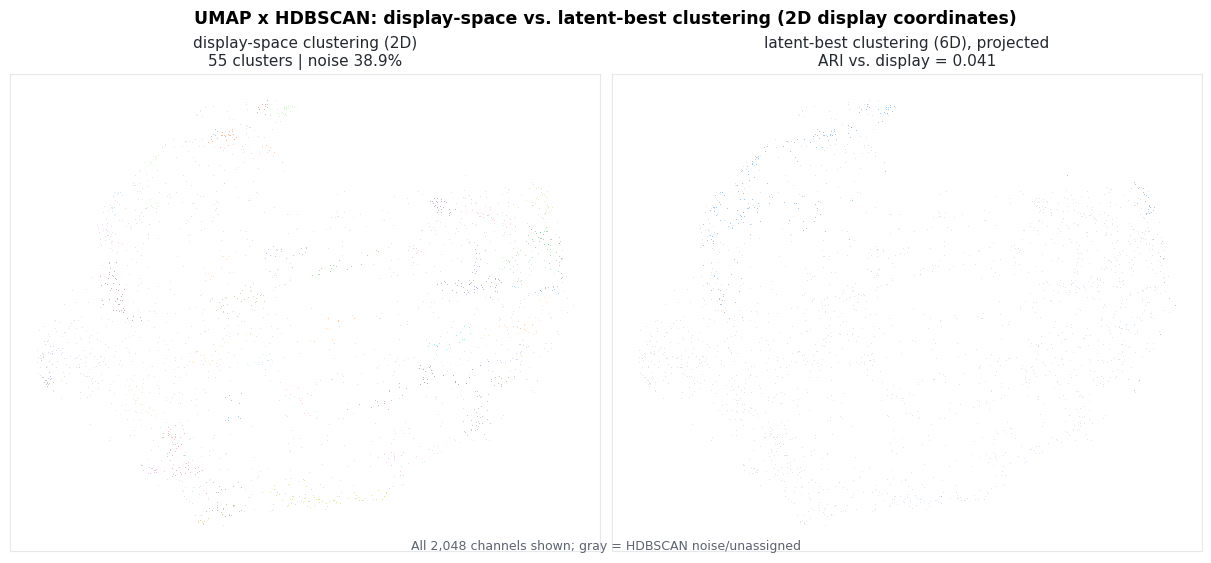

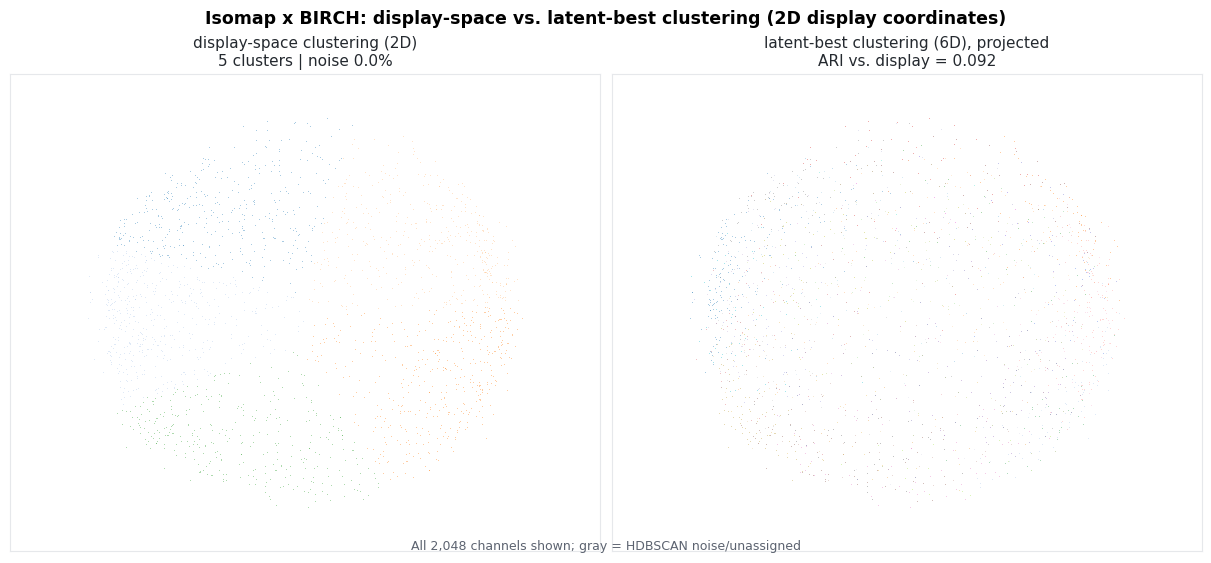

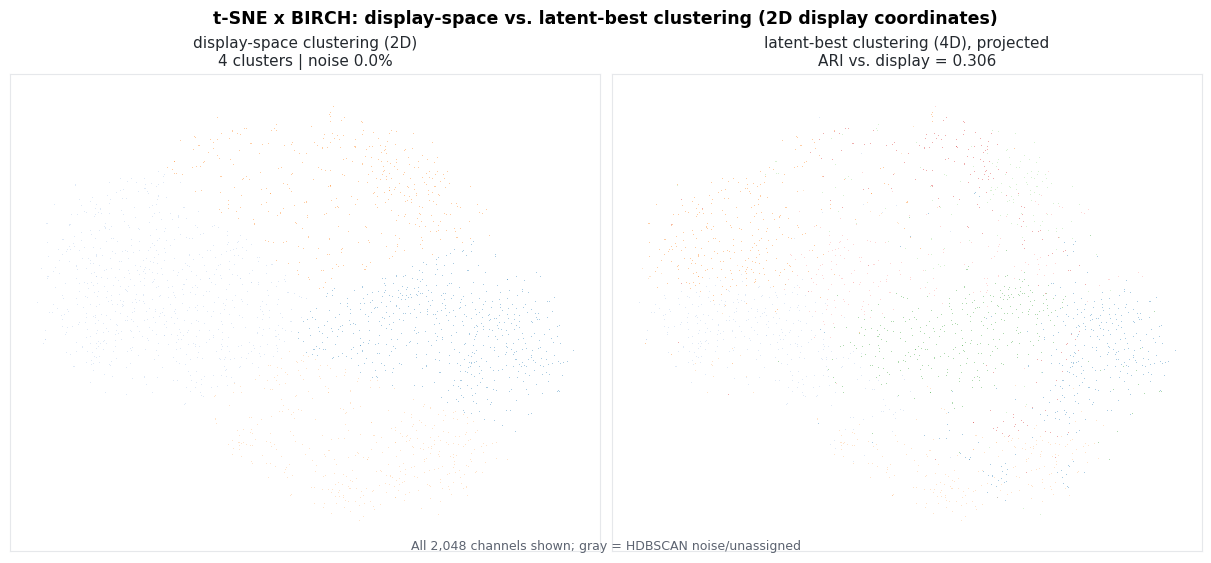

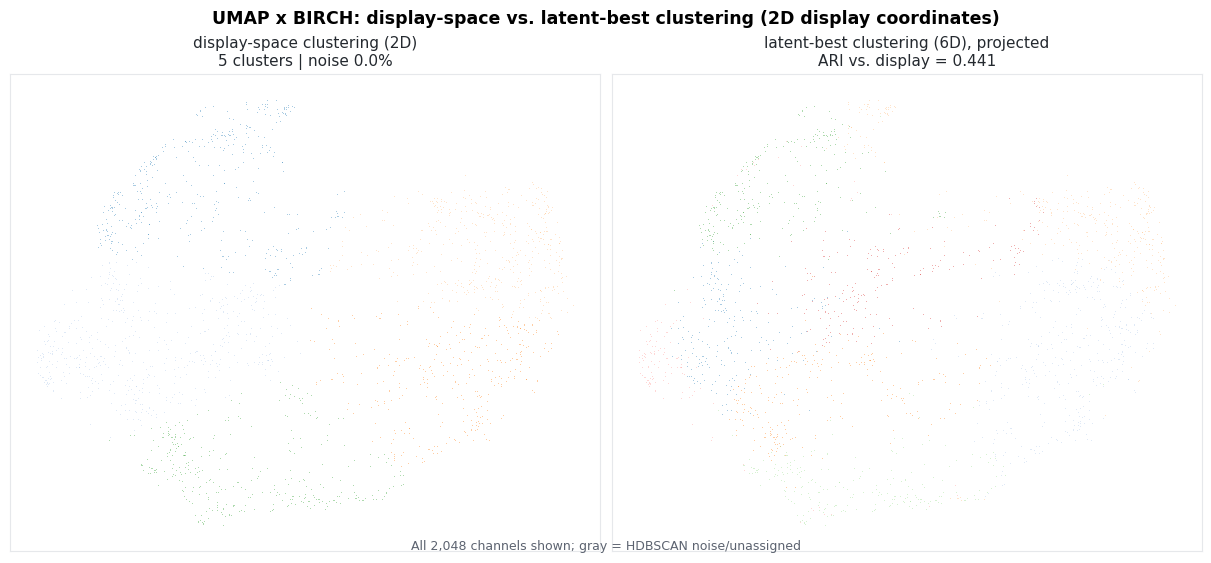

In [8]:
for clusterer in CLUSTER_ORDER:
    for reduction in REDUCTION_ORDER:
        path, ari = plot_comparison(reduction, clusterer, "display_2d", 2)
        if path is None:
            skipped_comparisons.append((reduction, clusterer, "display_2d"))
            continue
        comparison_records.append((clusterer, reduction, "display_2d", path))
        ari_records.append({"reduction_method": reduction, "clusterer": clusterer,
                             "display_role": "display_2d", "adjusted_rand_index": ari})


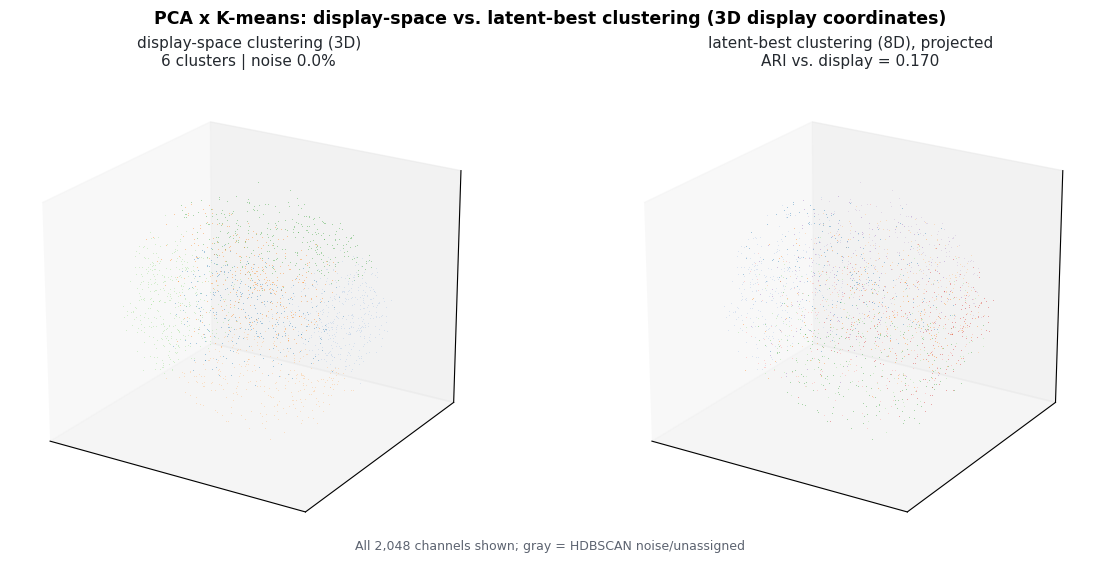

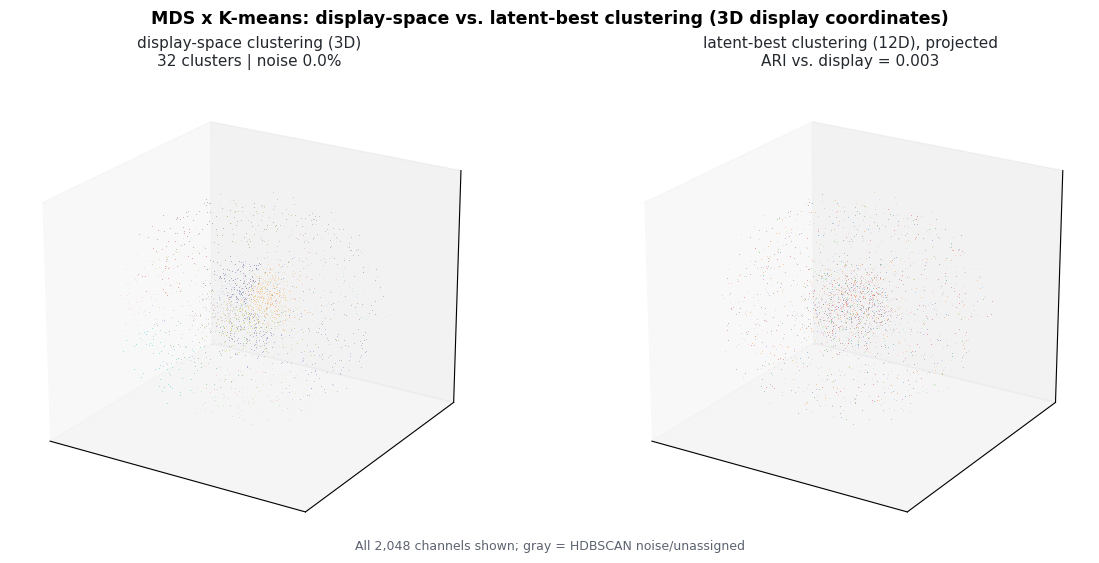

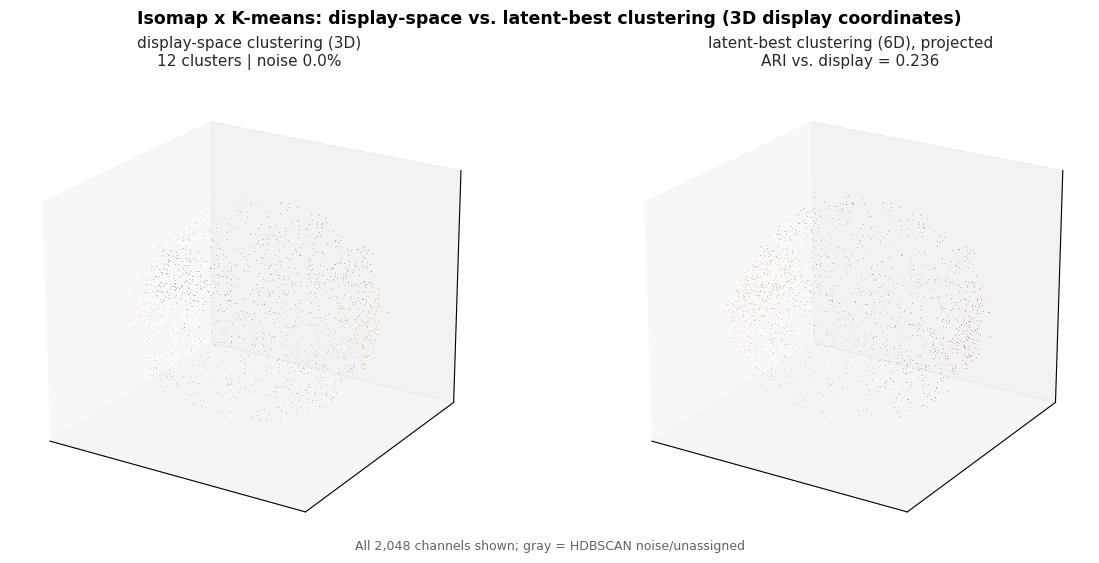

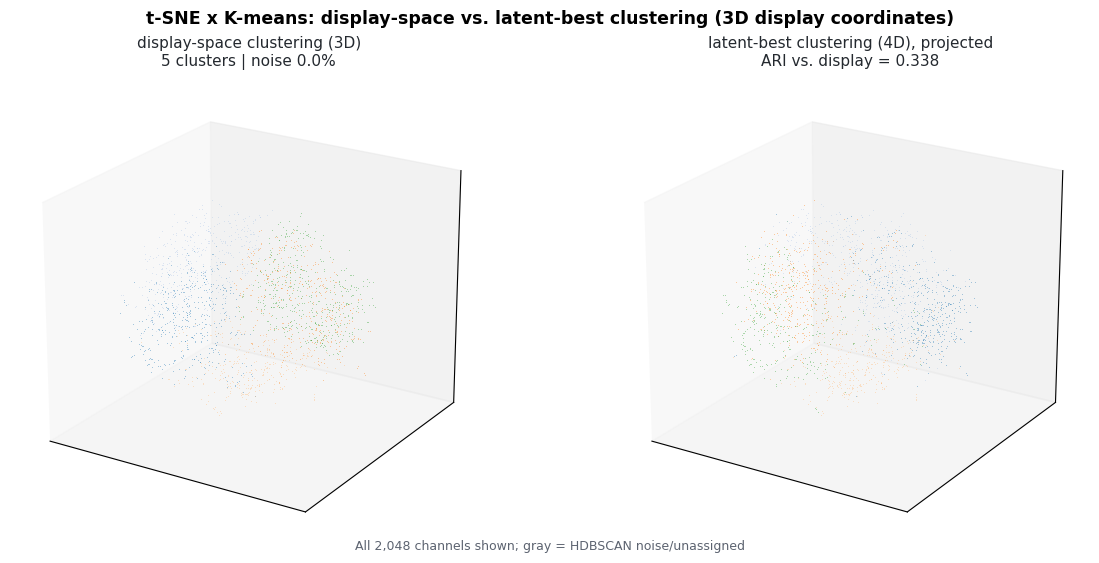

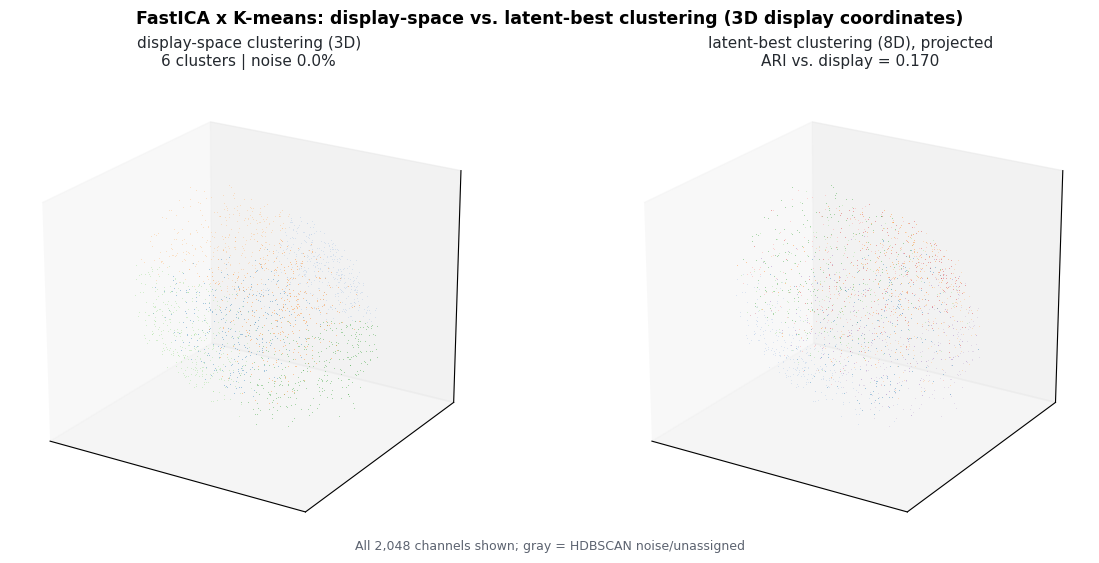

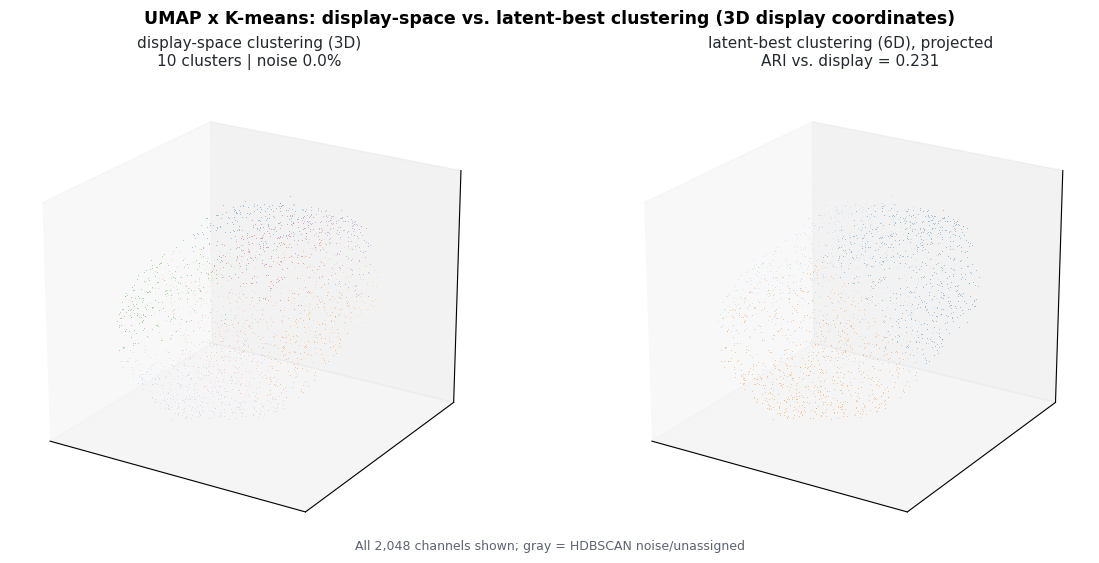

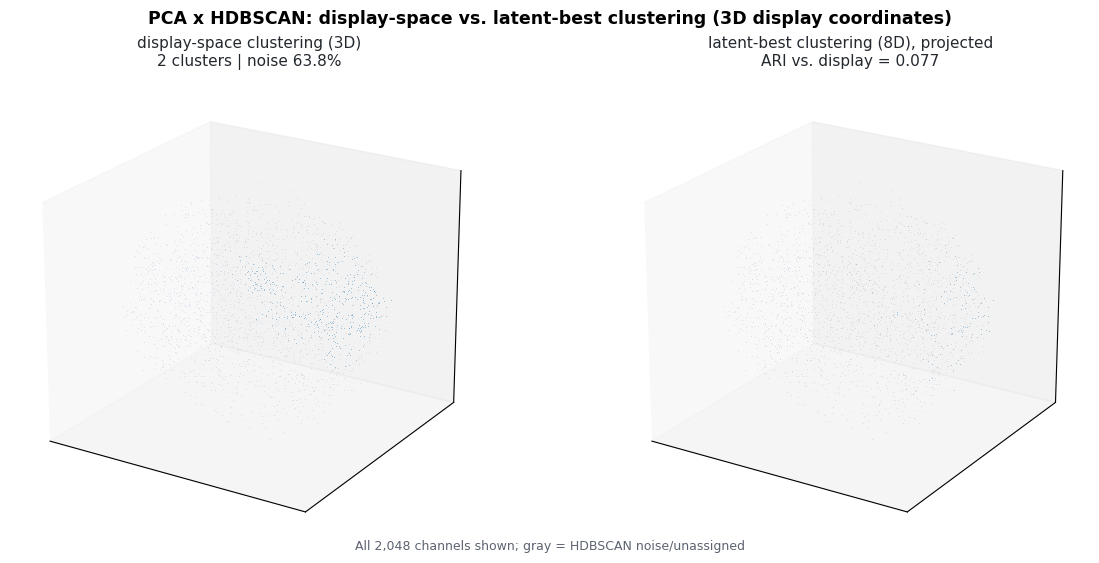

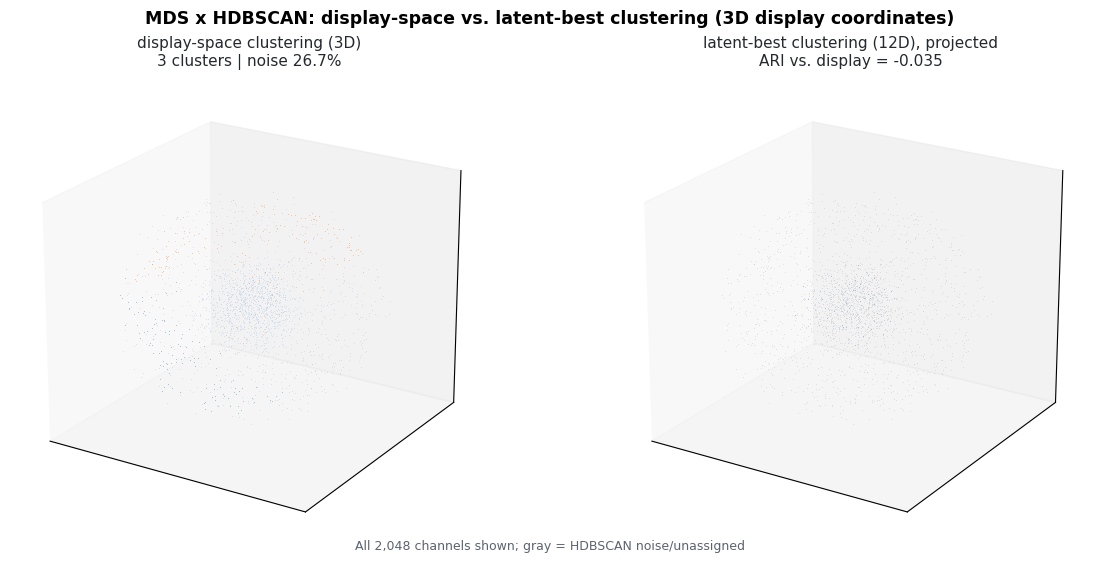

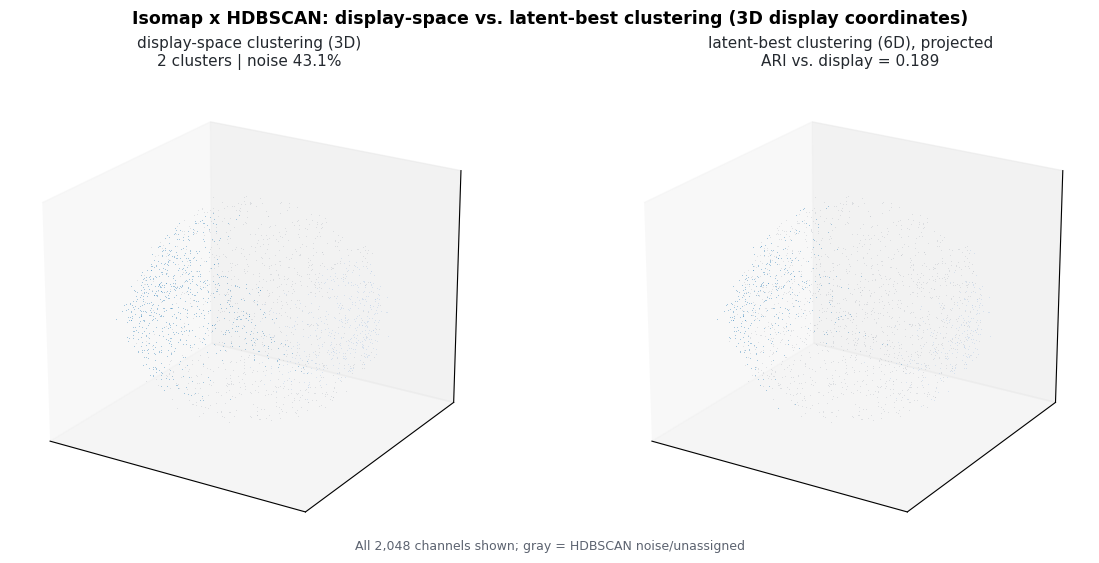

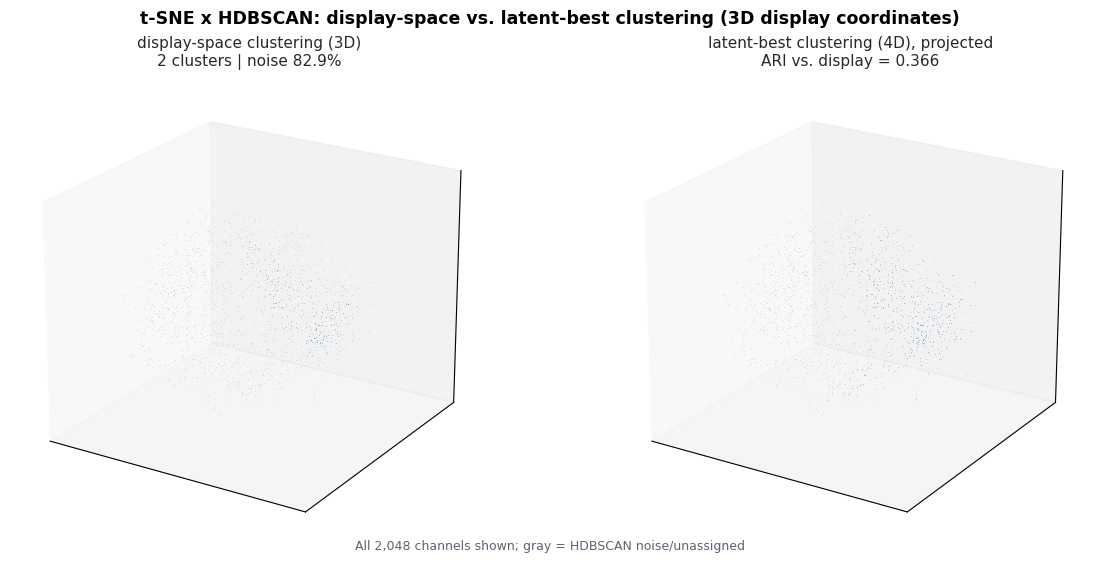

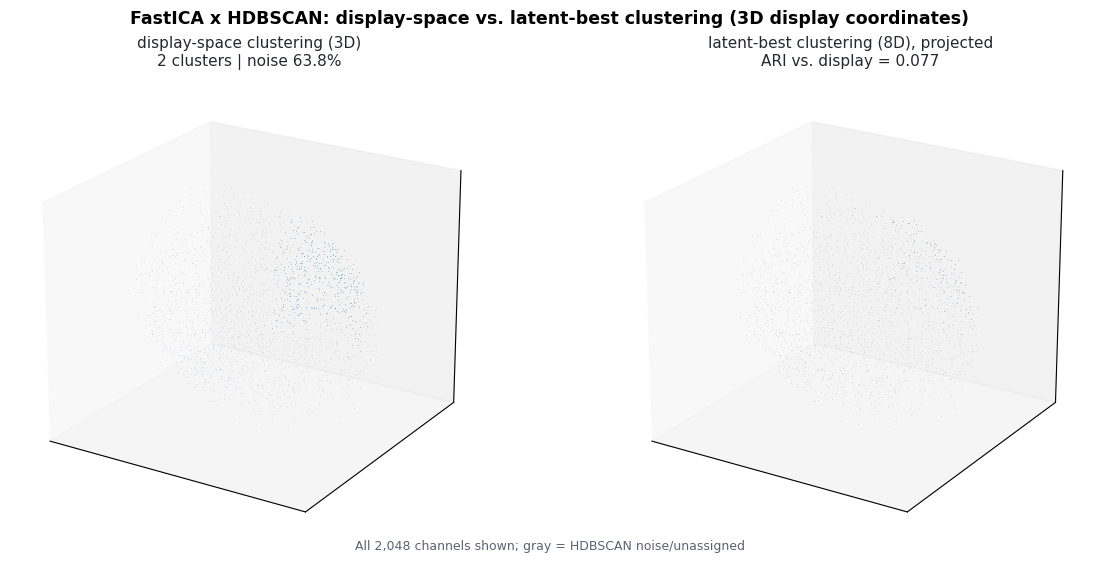

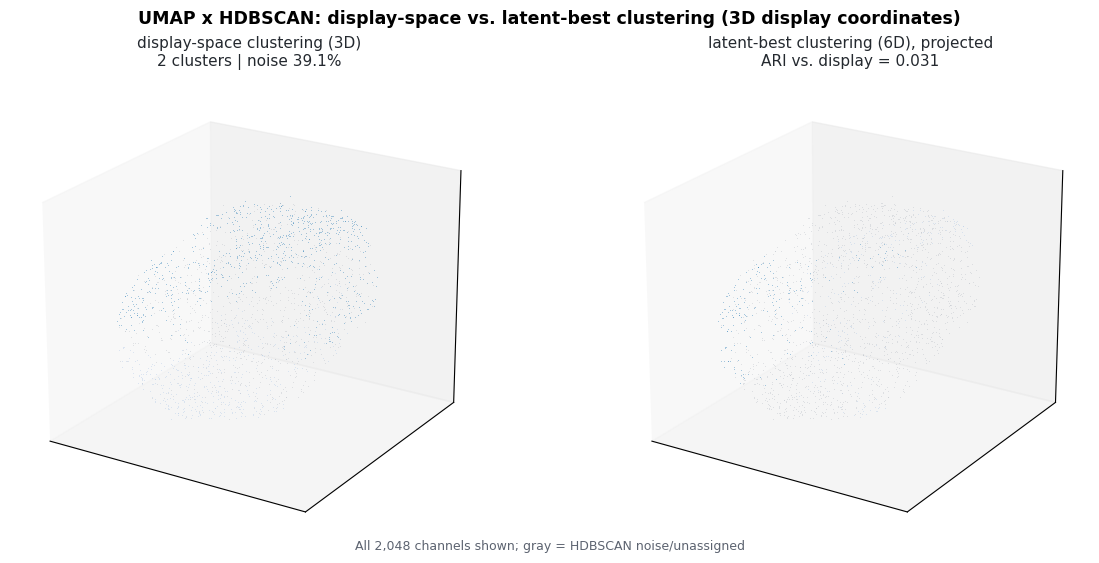

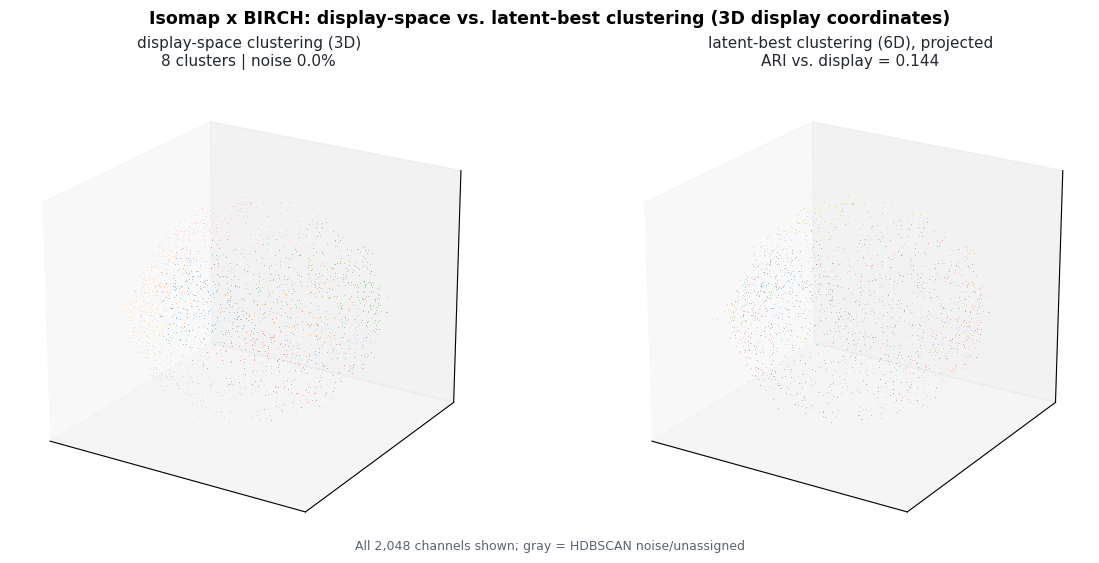

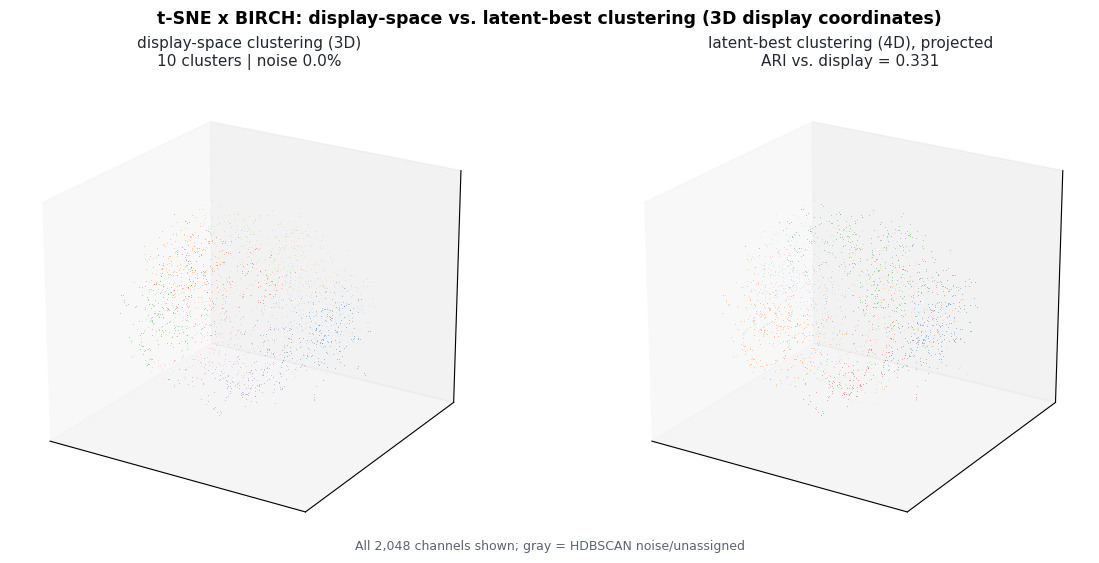

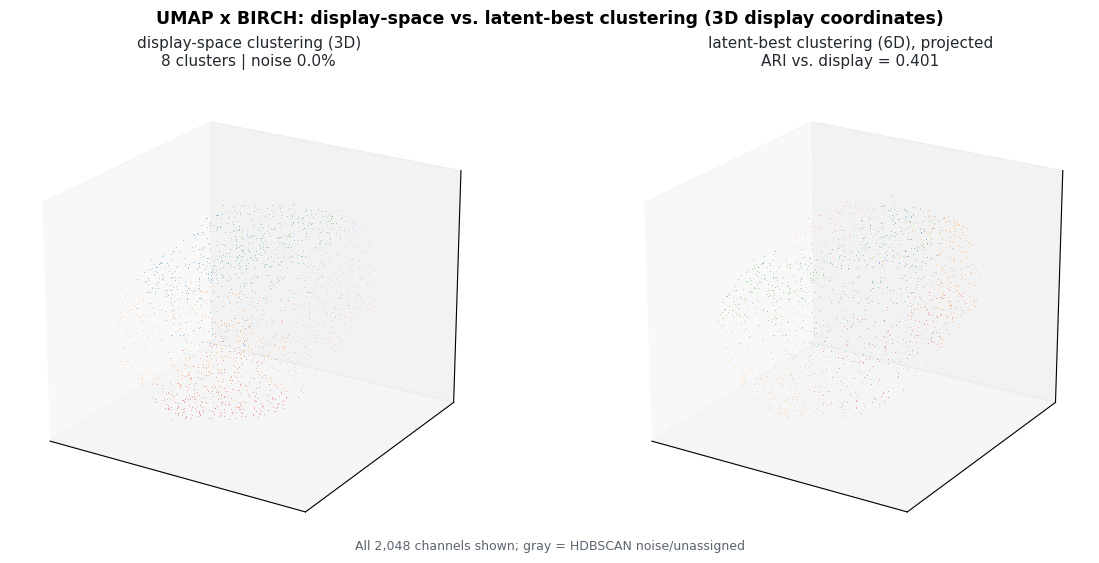

6 display-vs-latent-best comparisons skipped (no valid latent_best clustering for that reducer/clusterer):
  - pca / birch / display_2d
  - mds / birch / display_2d
  - fastica / birch / display_2d
  - pca / birch / display_3d
  - mds / birch / display_3d
  - fastica / birch / display_3d


In [9]:
for clusterer in CLUSTER_ORDER:
    for reduction in REDUCTION_ORDER:
        path, ari = plot_comparison(reduction, clusterer, "display_3d", 3)
        if path is None:
            skipped_comparisons.append((reduction, clusterer, "display_3d"))
            continue
        comparison_records.append((clusterer, reduction, "display_3d", path))
        ari_records.append({"reduction_method": reduction, "clusterer": clusterer,
                             "display_role": "display_3d", "adjusted_rand_index": ari})

if skipped_comparisons:
    print(f"{len(skipped_comparisons)} display-vs-latent-best comparisons skipped "
          f"(no valid latent_best clustering for that reducer/clusterer):")
    for reduction, clusterer, role in skipped_comparisons:
        print(f"  - {reduction} / {clusterer} / {role}")


In [10]:
ari_table = pd.DataFrame(ari_records).sort_values(
    ["reduction_method", "clusterer", "display_role"]
).reset_index(drop=True)
ari_table.to_csv(FIGURE_DIR / "latent_best_vs_display_ari.csv", index=False)
display(ari_table)

latent_dims = (
    latent_summary[latent_summary["selected"]]
    .set_index("method")["n_components"]
    .reindex(REDUCTION_ORDER)
)

per_method_mean_ari = ari_table.groupby("reduction_method")["adjusted_rand_index"].mean().reindex(REDUCTION_ORDER)
overall_mean_ari = ari_table["adjusted_rand_index"].mean()
lowest = ari_table.loc[ari_table["adjusted_rand_index"].idxmin()]
highest = ari_table.loc[ari_table["adjusted_rand_index"].idxmax()]

lines = [
    f"### Numbers: selected latent dimensionality and display-vs-latent-best agreement ({FAMILY})",
    "",
    "**Selected `latent_best` dimensionality per reducer** (elbow-selected, from Section 1):",
    "",
]
for method in REDUCTION_ORDER:
    dim = latent_dims.get(method)
    mean_ari = per_method_mean_ari.get(method)
    dim_txt = "n/a" if pd.isna(dim) else f"{int(dim)}D"
    ari_txt = "n/a (no comparisons succeeded)" if pd.isna(mean_ari) else f"{mean_ari:.3f}"
    lines.append(f"- **{DISPLAY_NAMES[method]}**: latent-best dimensionality = {dim_txt}; "
                 f"mean ARI vs. display-space labels (across clusterers/roles that succeeded) = {ari_txt}")
lines += [
    "",
    f"**Overall**: {len(ari_table)} of {len(CLUSTER_ORDER) * len(REDUCTION_ORDER) * 2} possible "
    f"(reducer, clusterer, 2D-or-3D-role) comparisons succeeded; "
    f"{len(skipped_comparisons)} skipped for lack of a valid `latent_best` clustering. "
    f"Mean ARI across all successful comparisons = **{overall_mean_ari:.3f}**.",
    "",
    f"- Lowest agreement: **{lowest['reduction_method']}** x "
    f"{lowest['clusterer']} ({lowest['display_role']}), ARI = {lowest['adjusted_rand_index']:.3f} — "
    "the visible 2D/3D grouping there is the weakest stand-in for the fuller-dimensional clustering.",
    f"- Highest agreement: **{highest['reduction_method']}** x {highest['clusterer']} "
    f"({highest['display_role']}), ARI = {highest['adjusted_rand_index']:.3f} — "
    "the display-space picture there is the most trustworthy proxy for the latent-best clustering.",
]
display(Markdown("\n".join(lines)))


,reduction_method,clusterer,display_role,adjusted_rand_index
0,fastica,hdbscan,display_2d,-0.031737
1,fastica,hdbscan,display_3d,0.076650
2,fastica,kmeans,display_2d,0.114980
3,fastica,kmeans,display_3d,0.169869
4,isomap,birch,display_2d,0.092378
5,isomap,birch,display_3d,0.144380
6,isomap,hdbscan,display_2d,0.155326
7,isomap,hdbscan,display_3d,0.189093
8,isomap,kmeans,display_2d,0.238133
9,isomap,kmeans,display_3d,0.235862


### Numbers: selected latent dimensionality and display-vs-latent-best agreement (topoomni_layer18_sheet_mp)

**Selected `latent_best` dimensionality per reducer** (elbow-selected, from Section 1):

- **PCA**: latent-best dimensionality = 8D; mean ARI vs. display-space labels (across clusterers/roles that succeeded) = 0.082
- **MDS**: latent-best dimensionality = 12D; mean ARI vs. display-space labels (across clusterers/roles that succeeded) = -0.007
- **Isomap**: latent-best dimensionality = 6D; mean ARI vs. display-space labels (across clusterers/roles that succeeded) = 0.176
- **t-SNE**: latent-best dimensionality = 4D; mean ARI vs. display-space labels (across clusterers/roles that succeeded) = 0.334
- **FastICA**: latent-best dimensionality = 8D; mean ARI vs. display-space labels (across clusterers/roles that succeeded) = 0.082
- **UMAP**: latent-best dimensionality = 6D; mean ARI vs. display-space labels (across clusterers/roles that succeeded) = 0.245

**Overall**: 30 of 36 possible (reducer, clusterer, 2D-or-3D-role) comparisons succeeded; 6 skipped for lack of a valid `latent_best` clustering. Mean ARI across all successful comparisons = **0.172**.

- Lowest agreement: **mds** x hdbscan (display_3d), ARI = -0.035 — the visible 2D/3D grouping there is the weakest stand-in for the fuller-dimensional clustering.
- Highest agreement: **umap** x birch (display_2d), ARI = 0.441 — the display-space picture there is the most trustworthy proxy for the latent-best clustering.

In [11]:
figure_index = pd.DataFrame(
    figure_records, columns=["clustering_method", "reduction_method", "selection_role", "figure_path"]
)
figure_index.to_csv(FIGURE_DIR / "scatterplot_index.csv", index=False)
display(figure_index)
assert len(figure_index) == 36, f"Expected 36 scatterplots, got {len(figure_index)}"
assert all(Path(path).exists() for path in figure_index["figure_path"])

comparison_index = pd.DataFrame(
    comparison_records, columns=["clustering_method", "reduction_method", "selection_role", "figure_path"]
)
comparison_index.to_csv(FIGURE_DIR / "comparison_index.csv", index=False)
display(comparison_index)
expected_comparisons = len(CLUSTER_ORDER) * len(REDUCTION_ORDER) * 2 - len(skipped_comparisons)
assert len(comparison_index) == expected_comparisons, (
    f"Expected {expected_comparisons} comparison figures "
    f"(36 minus {len(skipped_comparisons)} skipped), got {len(comparison_index)}"
)
assert all(Path(path).exists() for path in comparison_index["figure_path"])
assert len(ari_records) == len(comparison_index)

all_pngs = sorted(FIGURE_DIR.glob("*.png"))
expected_total_pngs = 45 + len(comparison_index)
print(f"Total PNGs in figures/: {len(all_pngs)} (expected {expected_total_pngs})")
assert len(all_pngs) == expected_total_pngs, (
    f"Expected {expected_total_pngs} total figures (6 dimensionality + 3 clustering-selection "
    f"+ 36 scatterplots + {len(comparison_index)} comparisons), got {len(all_pngs)}"
)
print(f"Family: {FAMILY} | manifest verified: every claimed figure exists on disk.")


,clustering_method,reduction_method,selection_role,figure_path
0,kmeans,pca,display_2d,/home/amin/Research/Representation/Movie/outpu...
1,kmeans,mds,display_2d,/home/amin/Research/Representation/Movie/outpu...
2,kmeans,isomap,display_2d,/home/amin/Research/Representation/Movie/outpu...
3,kmeans,tsne,display_2d,/home/amin/Research/Representation/Movie/outpu...
4,kmeans,fastica,display_2d,/home/amin/Research/Representation/Movie/outpu...
5,kmeans,umap,display_2d,/home/amin/Research/Representation/Movie/outpu...
6,hdbscan,pca,display_2d,/home/amin/Research/Representation/Movie/outpu...
7,hdbscan,mds,display_2d,/home/amin/Research/Representation/Movie/outpu...
8,hdbscan,isomap,display_2d,/home/amin/Research/Representation/Movie/outpu...
9,hdbscan,tsne,display_2d,/home/amin/Research/Representation/Movie/outpu...


,clustering_method,reduction_method,selection_role,figure_path
0,kmeans,pca,display_2d,/home/amin/Research/Representation/Movie/outpu...
1,kmeans,mds,display_2d,/home/amin/Research/Representation/Movie/outpu...
2,kmeans,isomap,display_2d,/home/amin/Research/Representation/Movie/outpu...
3,kmeans,tsne,display_2d,/home/amin/Research/Representation/Movie/outpu...
4,kmeans,fastica,display_2d,/home/amin/Research/Representation/Movie/outpu...
5,kmeans,umap,display_2d,/home/amin/Research/Representation/Movie/outpu...
6,hdbscan,pca,display_2d,/home/amin/Research/Representation/Movie/outpu...
7,hdbscan,mds,display_2d,/home/amin/Research/Representation/Movie/outpu...
8,hdbscan,isomap,display_2d,/home/amin/Research/Representation/Movie/outpu...
9,hdbscan,tsne,display_2d,/home/amin/Research/Representation/Movie/outpu...


Total PNGs in figures/: 75 (expected 75)
Family: topoomni_layer18_sheet_mp | manifest verified: every claimed figure exists on disk.


## Takeaways

- **Dimensionality selection (Section 1):** each reducer's elbow-selected latent-best
  dimension, the hyperparameters it sweeps, and why that dimension won are shown per
  reducer, grounded in `dimension_selection_sweep.csv` / `selected_latent_dimensions.csv`.
- **Clustering selection (Section 2):** each algorithm's full hyperparameter landscape
  across all 6 reducers (2D and 3D), correctly ordered on the swept parameter and
  faceted by the second parameter for HDBSCAN/BIRCH, with the winning combination
  starred.
- **Scatterplots (Sections 3-4):** 36 individual figures show the display-space (2D/3D)
  cluster assignments, every channel plotted. HDBSCAN gray points are unassigned/noise.
- **Display-space vs. latent-best (Section 5):** the elbow-selected `latent_best`
  dimension's cluster labels — fit with more of each reduction's structure retained than
  the 2-3-D pictures above use — are projected onto the same display coordinates and
  compared to the display-space clustering via adjusted Rand index. See Section 5's
  numbers cell for the per-reducer ARI values and which combinations to trust for this
  family; re-run with a different `FAMILY` in the config cell to see the same comparison
  for `nemotron_layer18_mp` or `peav`.
- Use `selected_clusterings_combined.csv` and the per-map CSVs under `selected_maps/` for
  channel-to-cluster lookups. These scatterplots show separation in reduced feature space
  only.
